Dataset loaded successfully
Shape: (50000, 18)


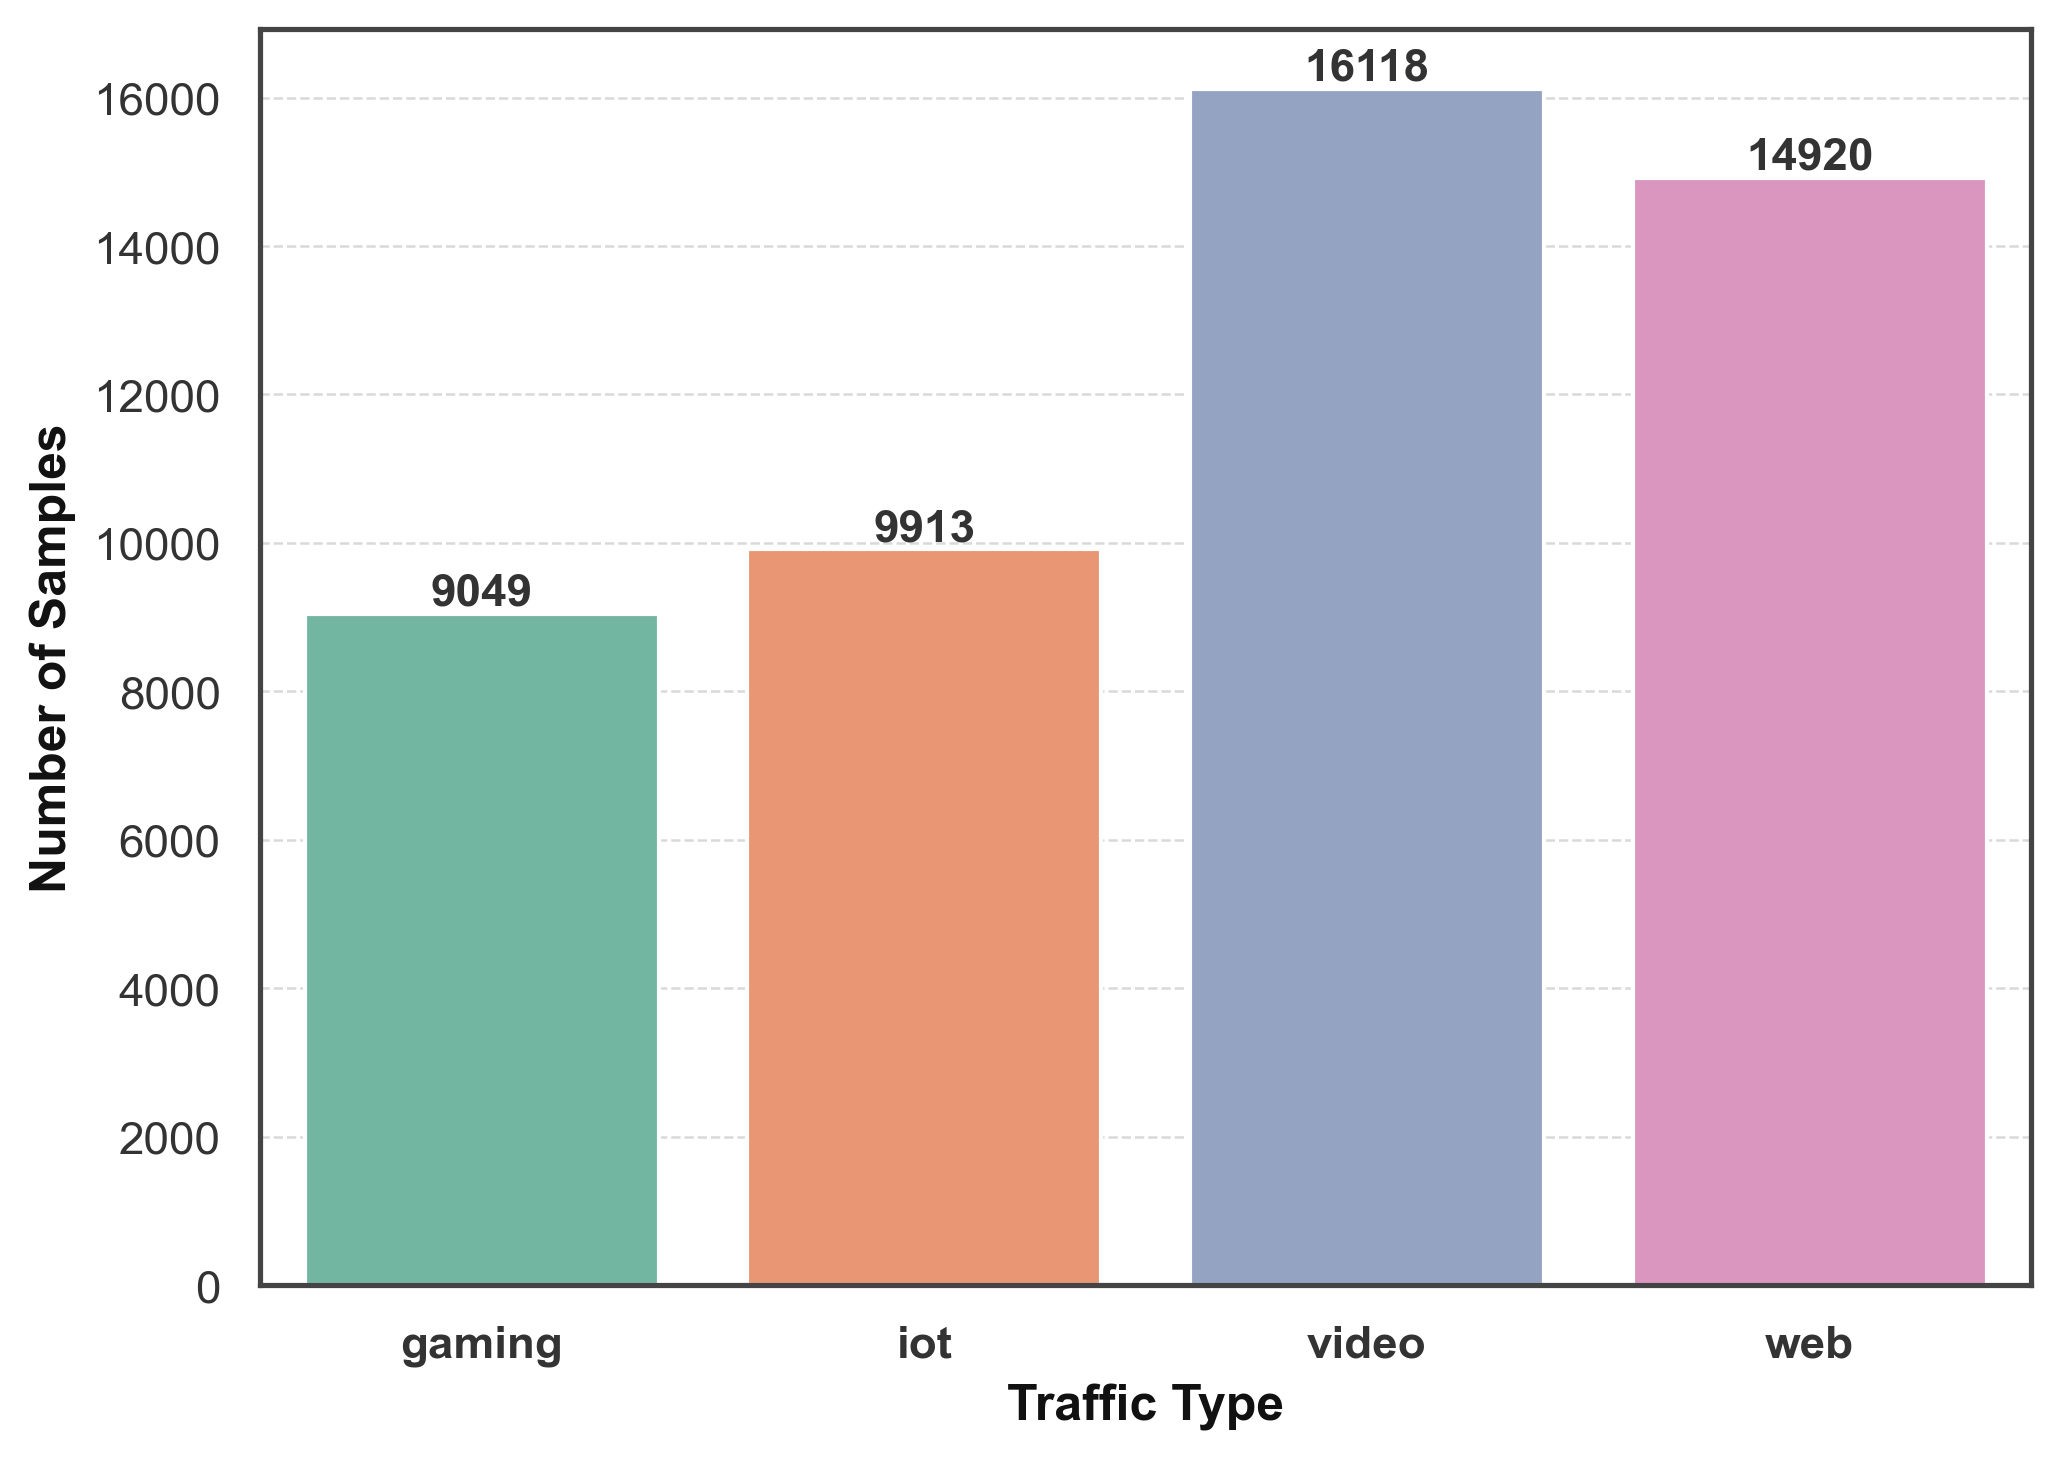

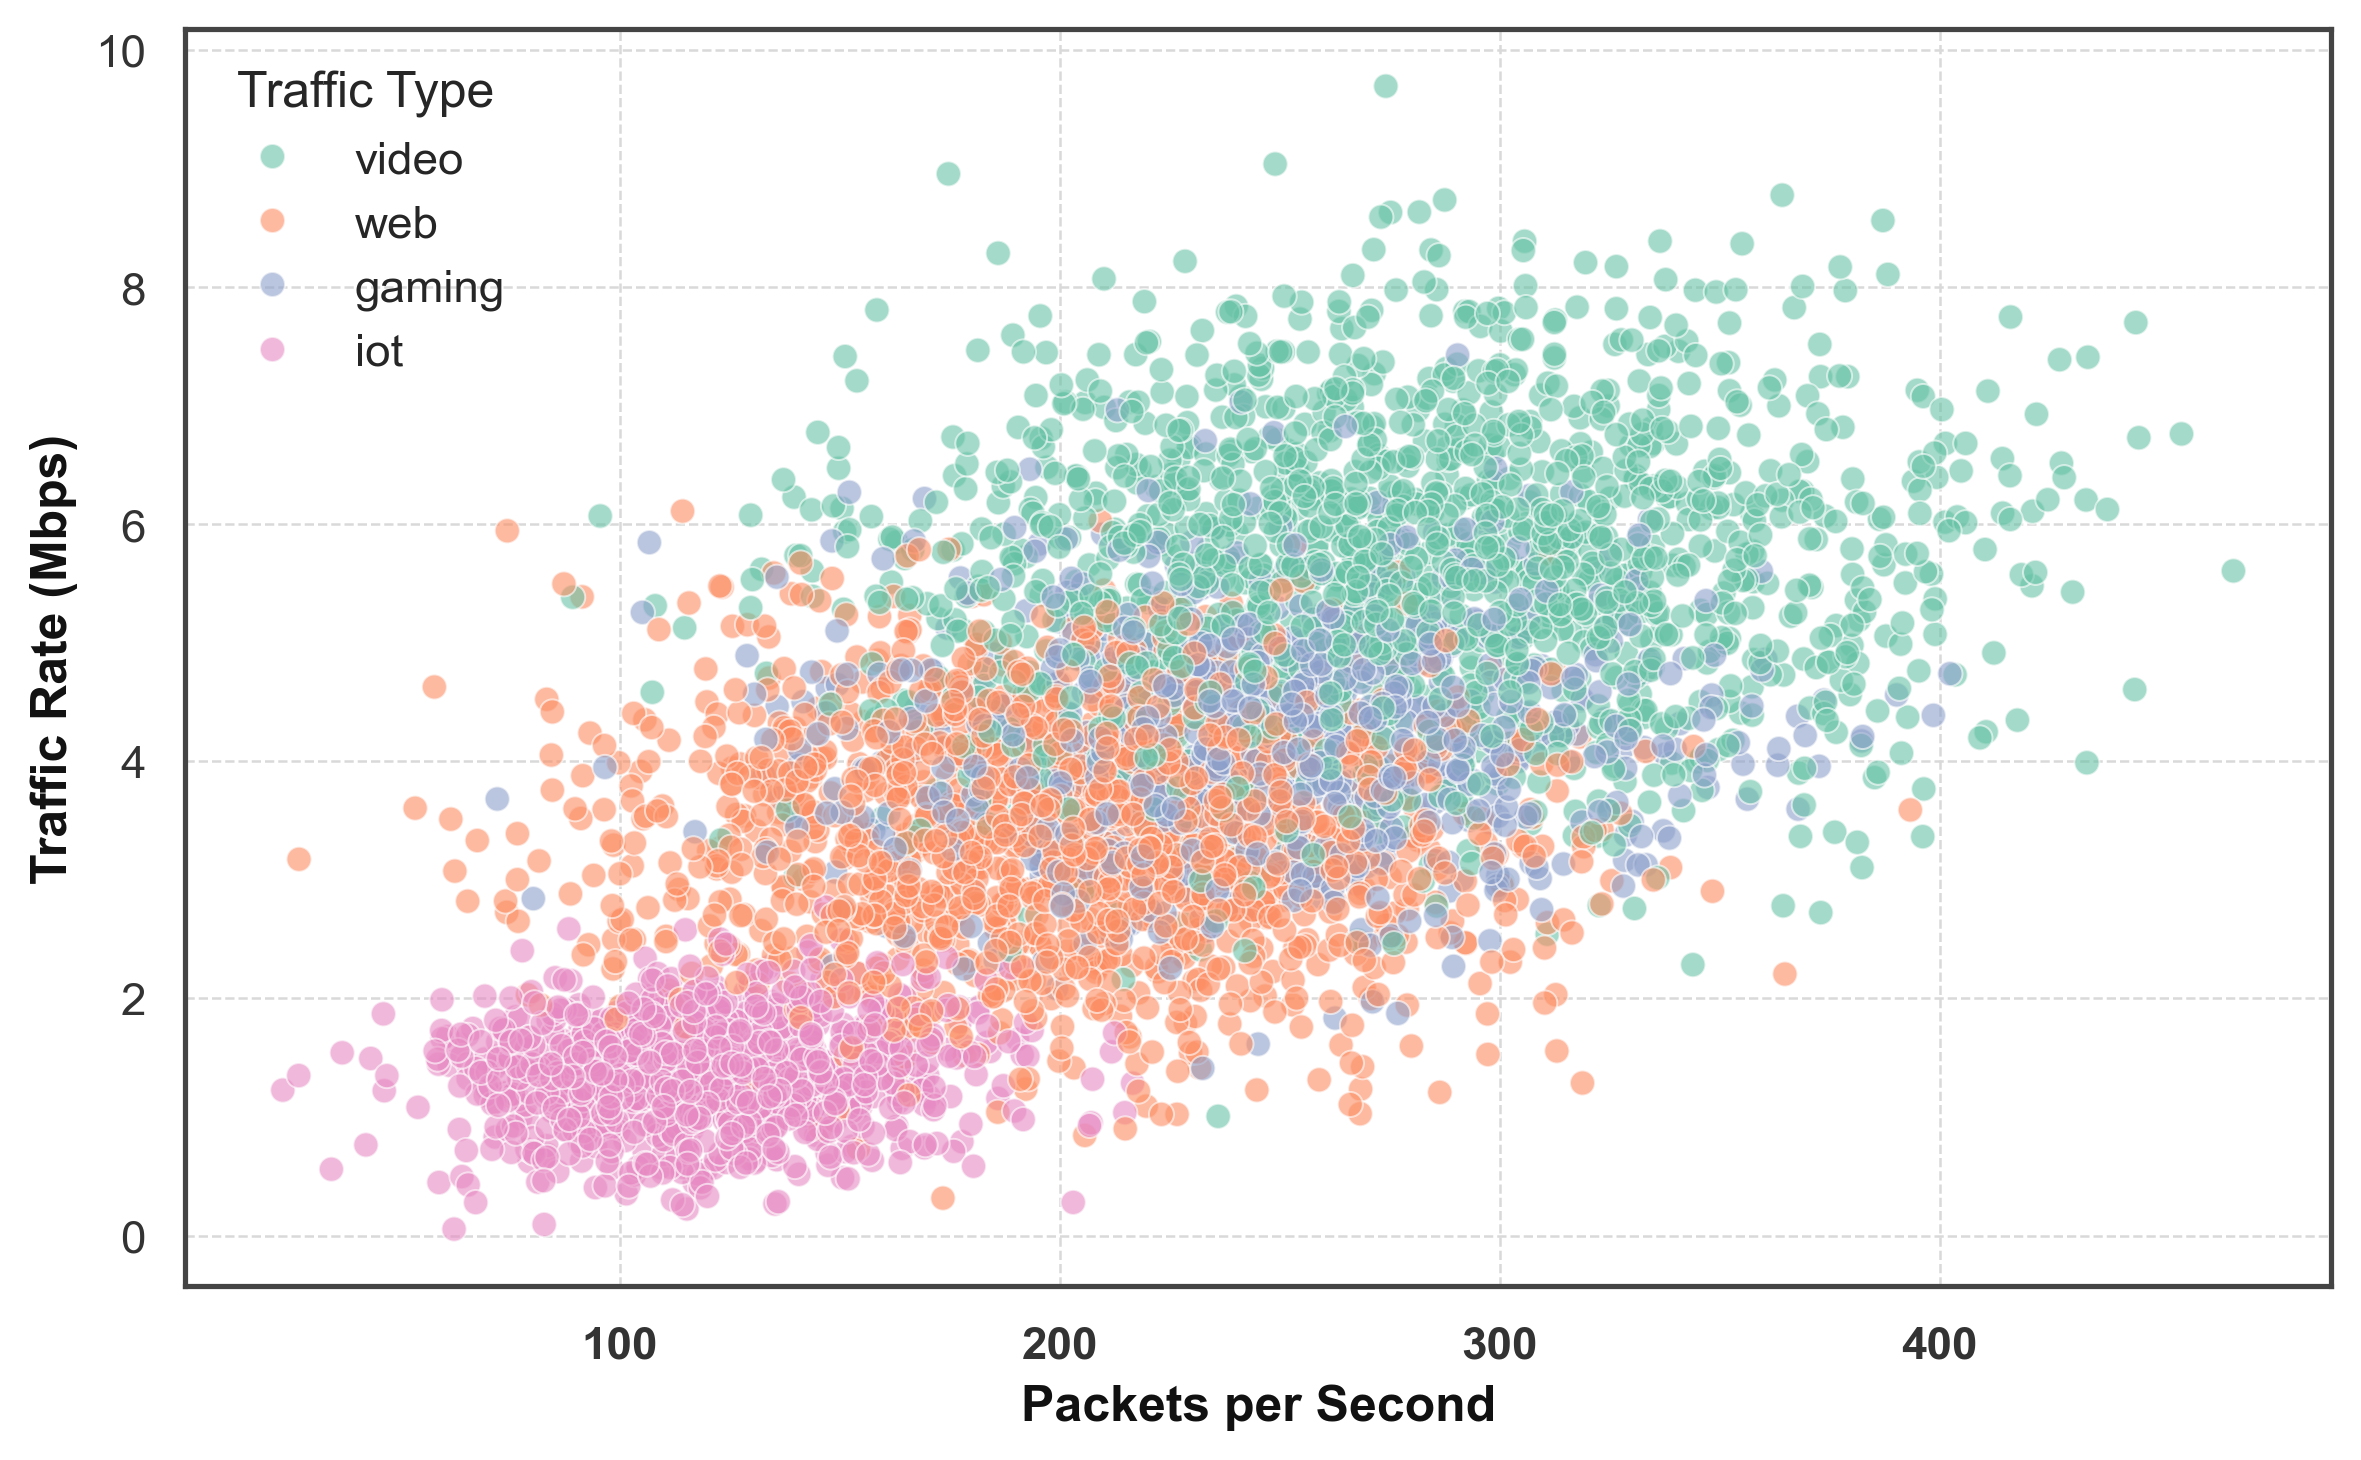

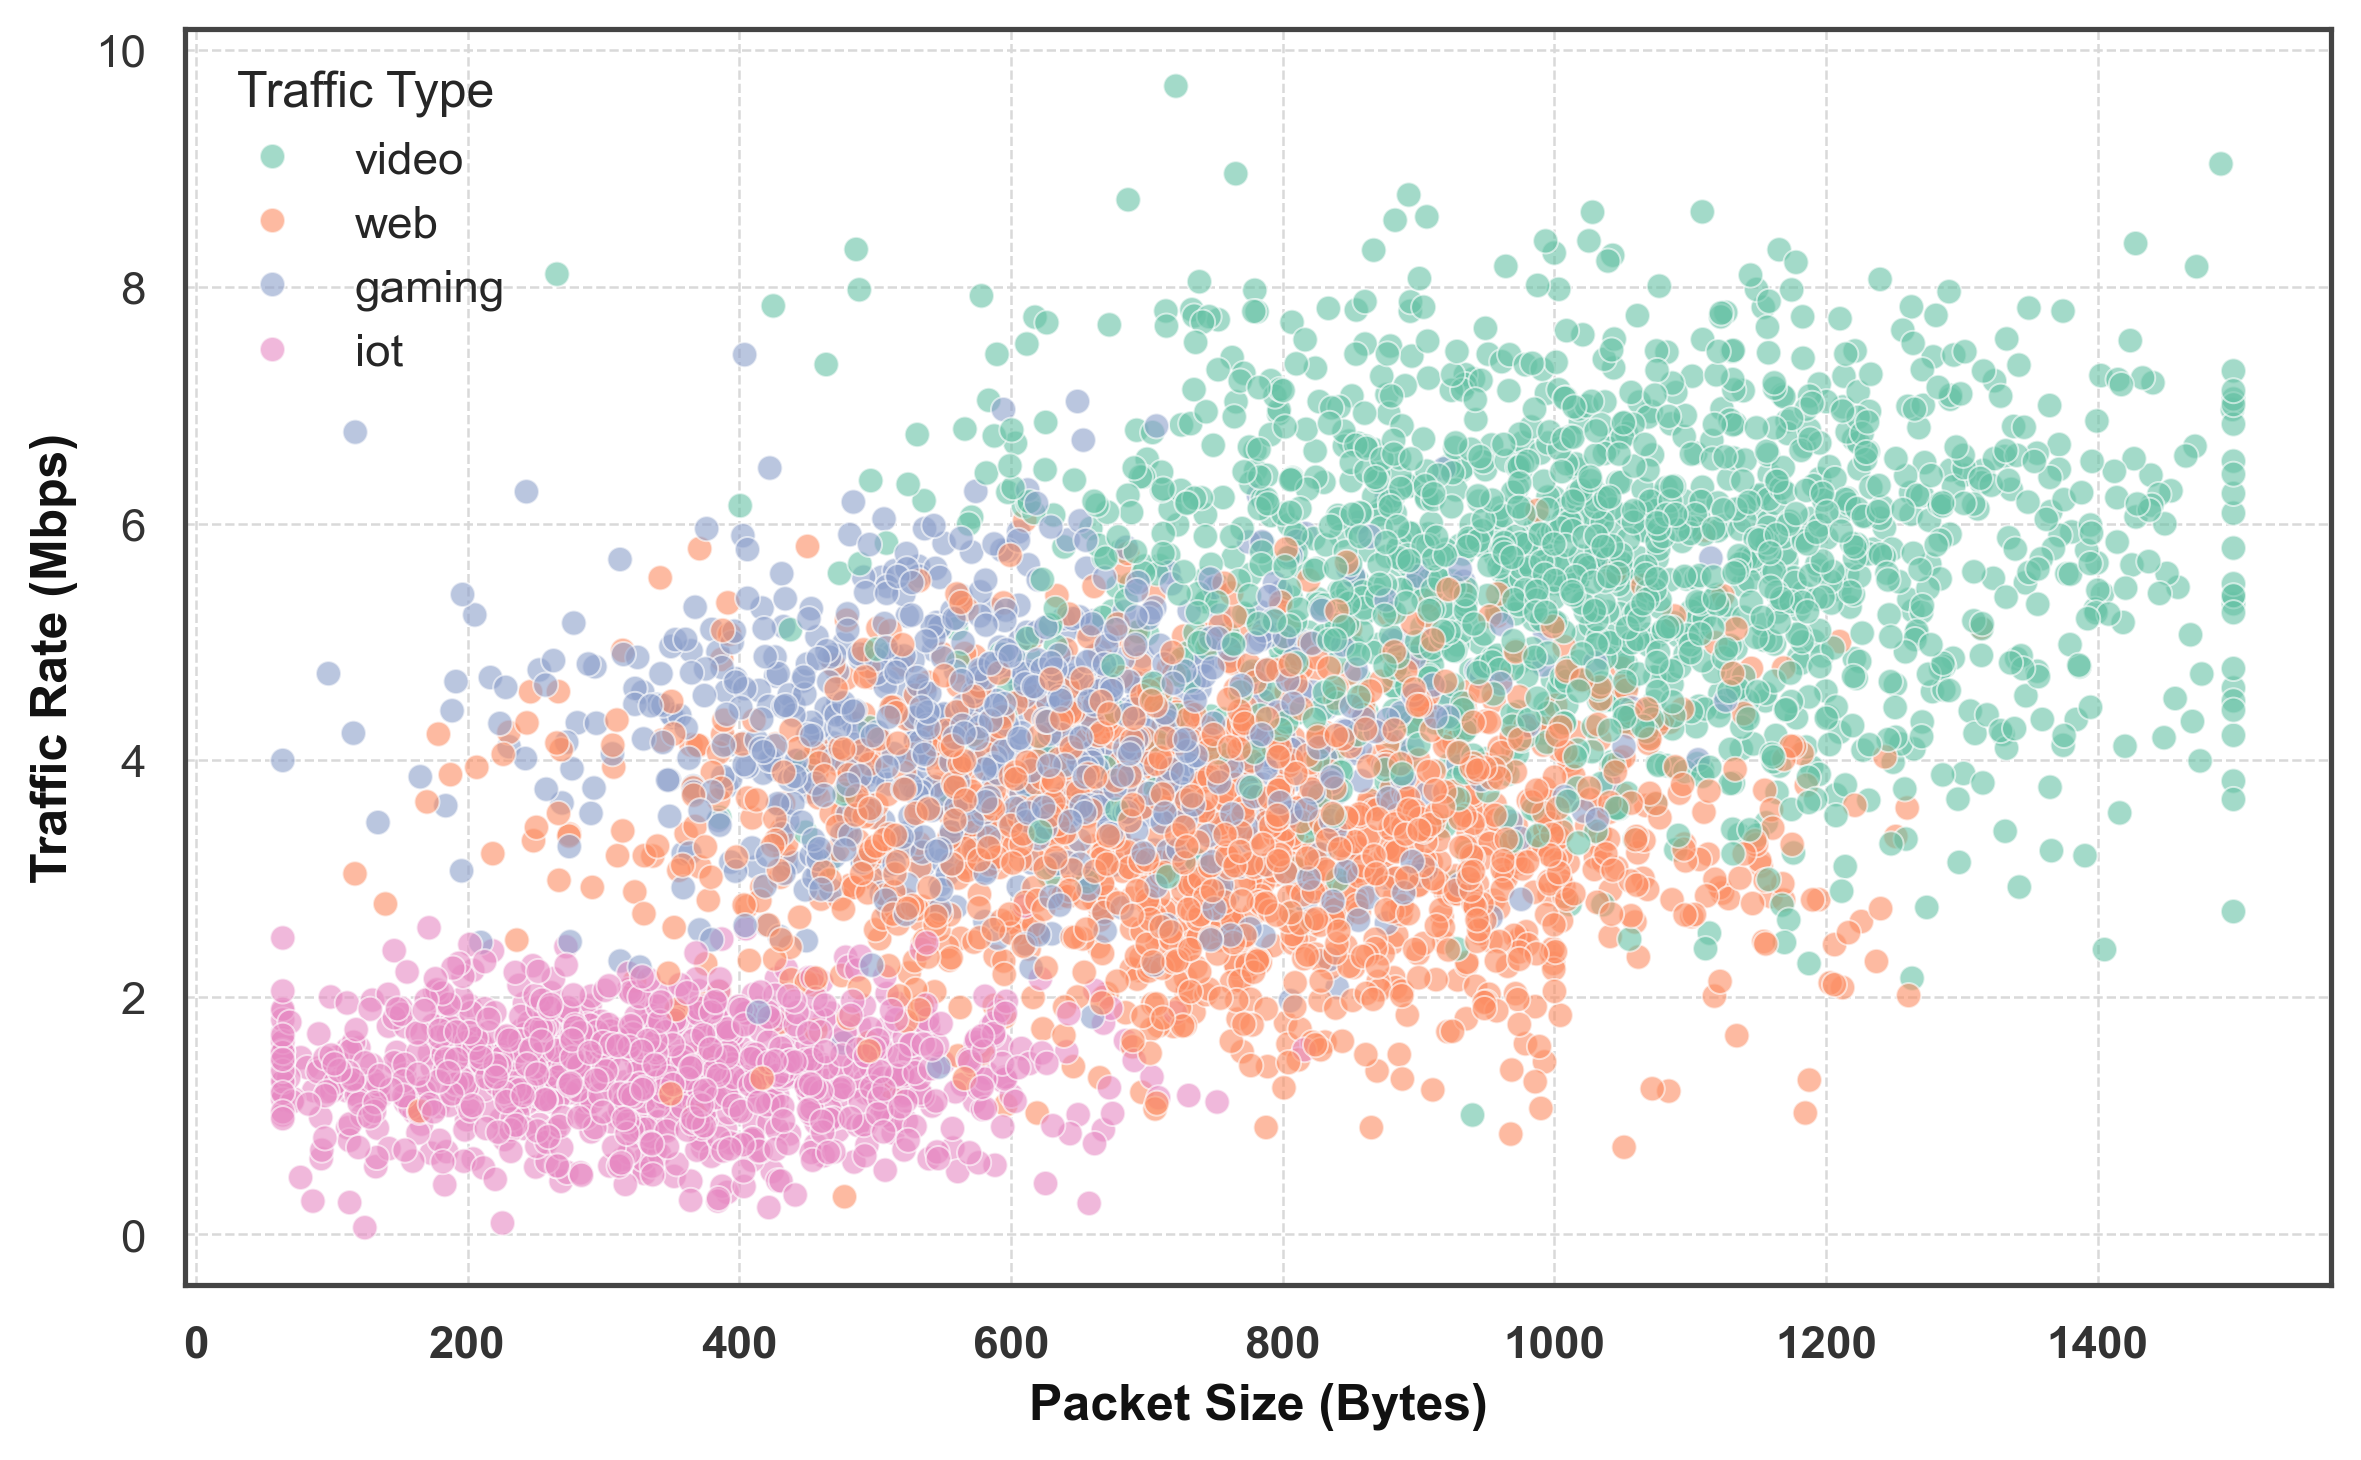

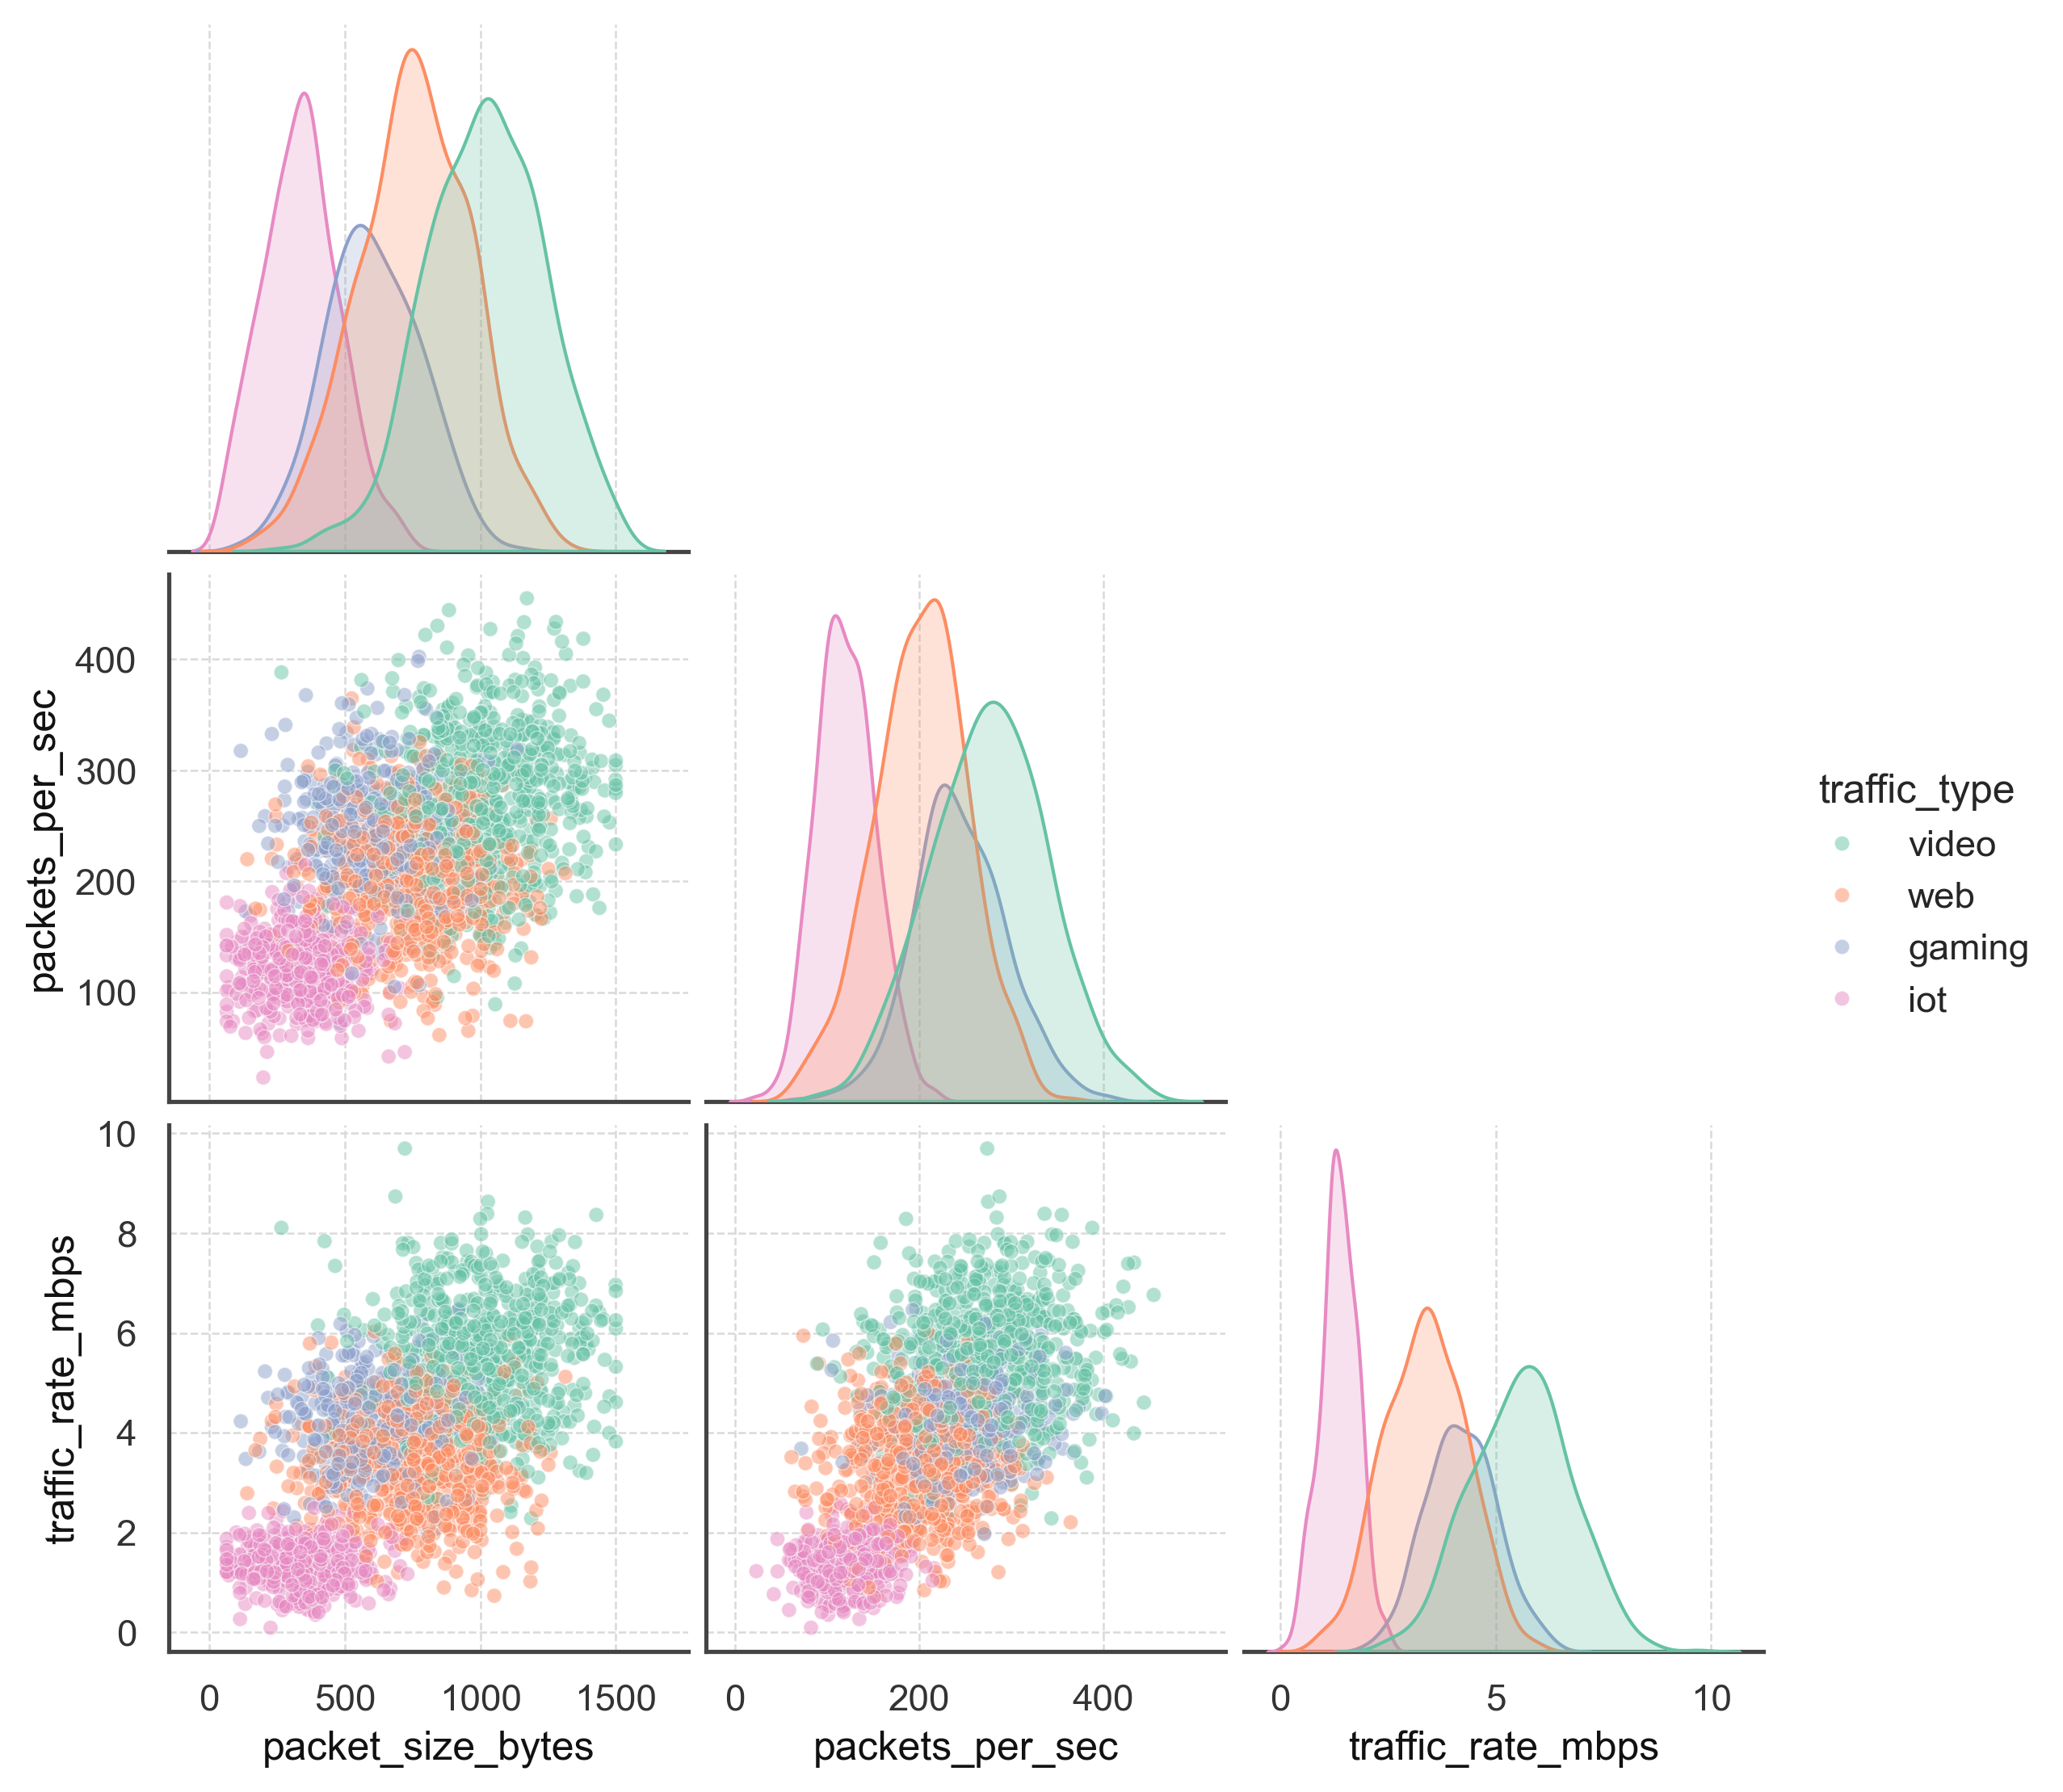


Overfitting Analysis:
           Model  Train Accuracy  Test Accuracy  Train F1-score  \
0            KNN        0.842714       0.799067        0.842078   
1  Random Forest        0.824057       0.811200        0.820198   
2            SVM        0.811514       0.804333        0.814966   

   Test F1-score  Overfitting Gap  
0       0.798222         0.043856  
1       0.807291         0.012907  
2       0.807746         0.007220  


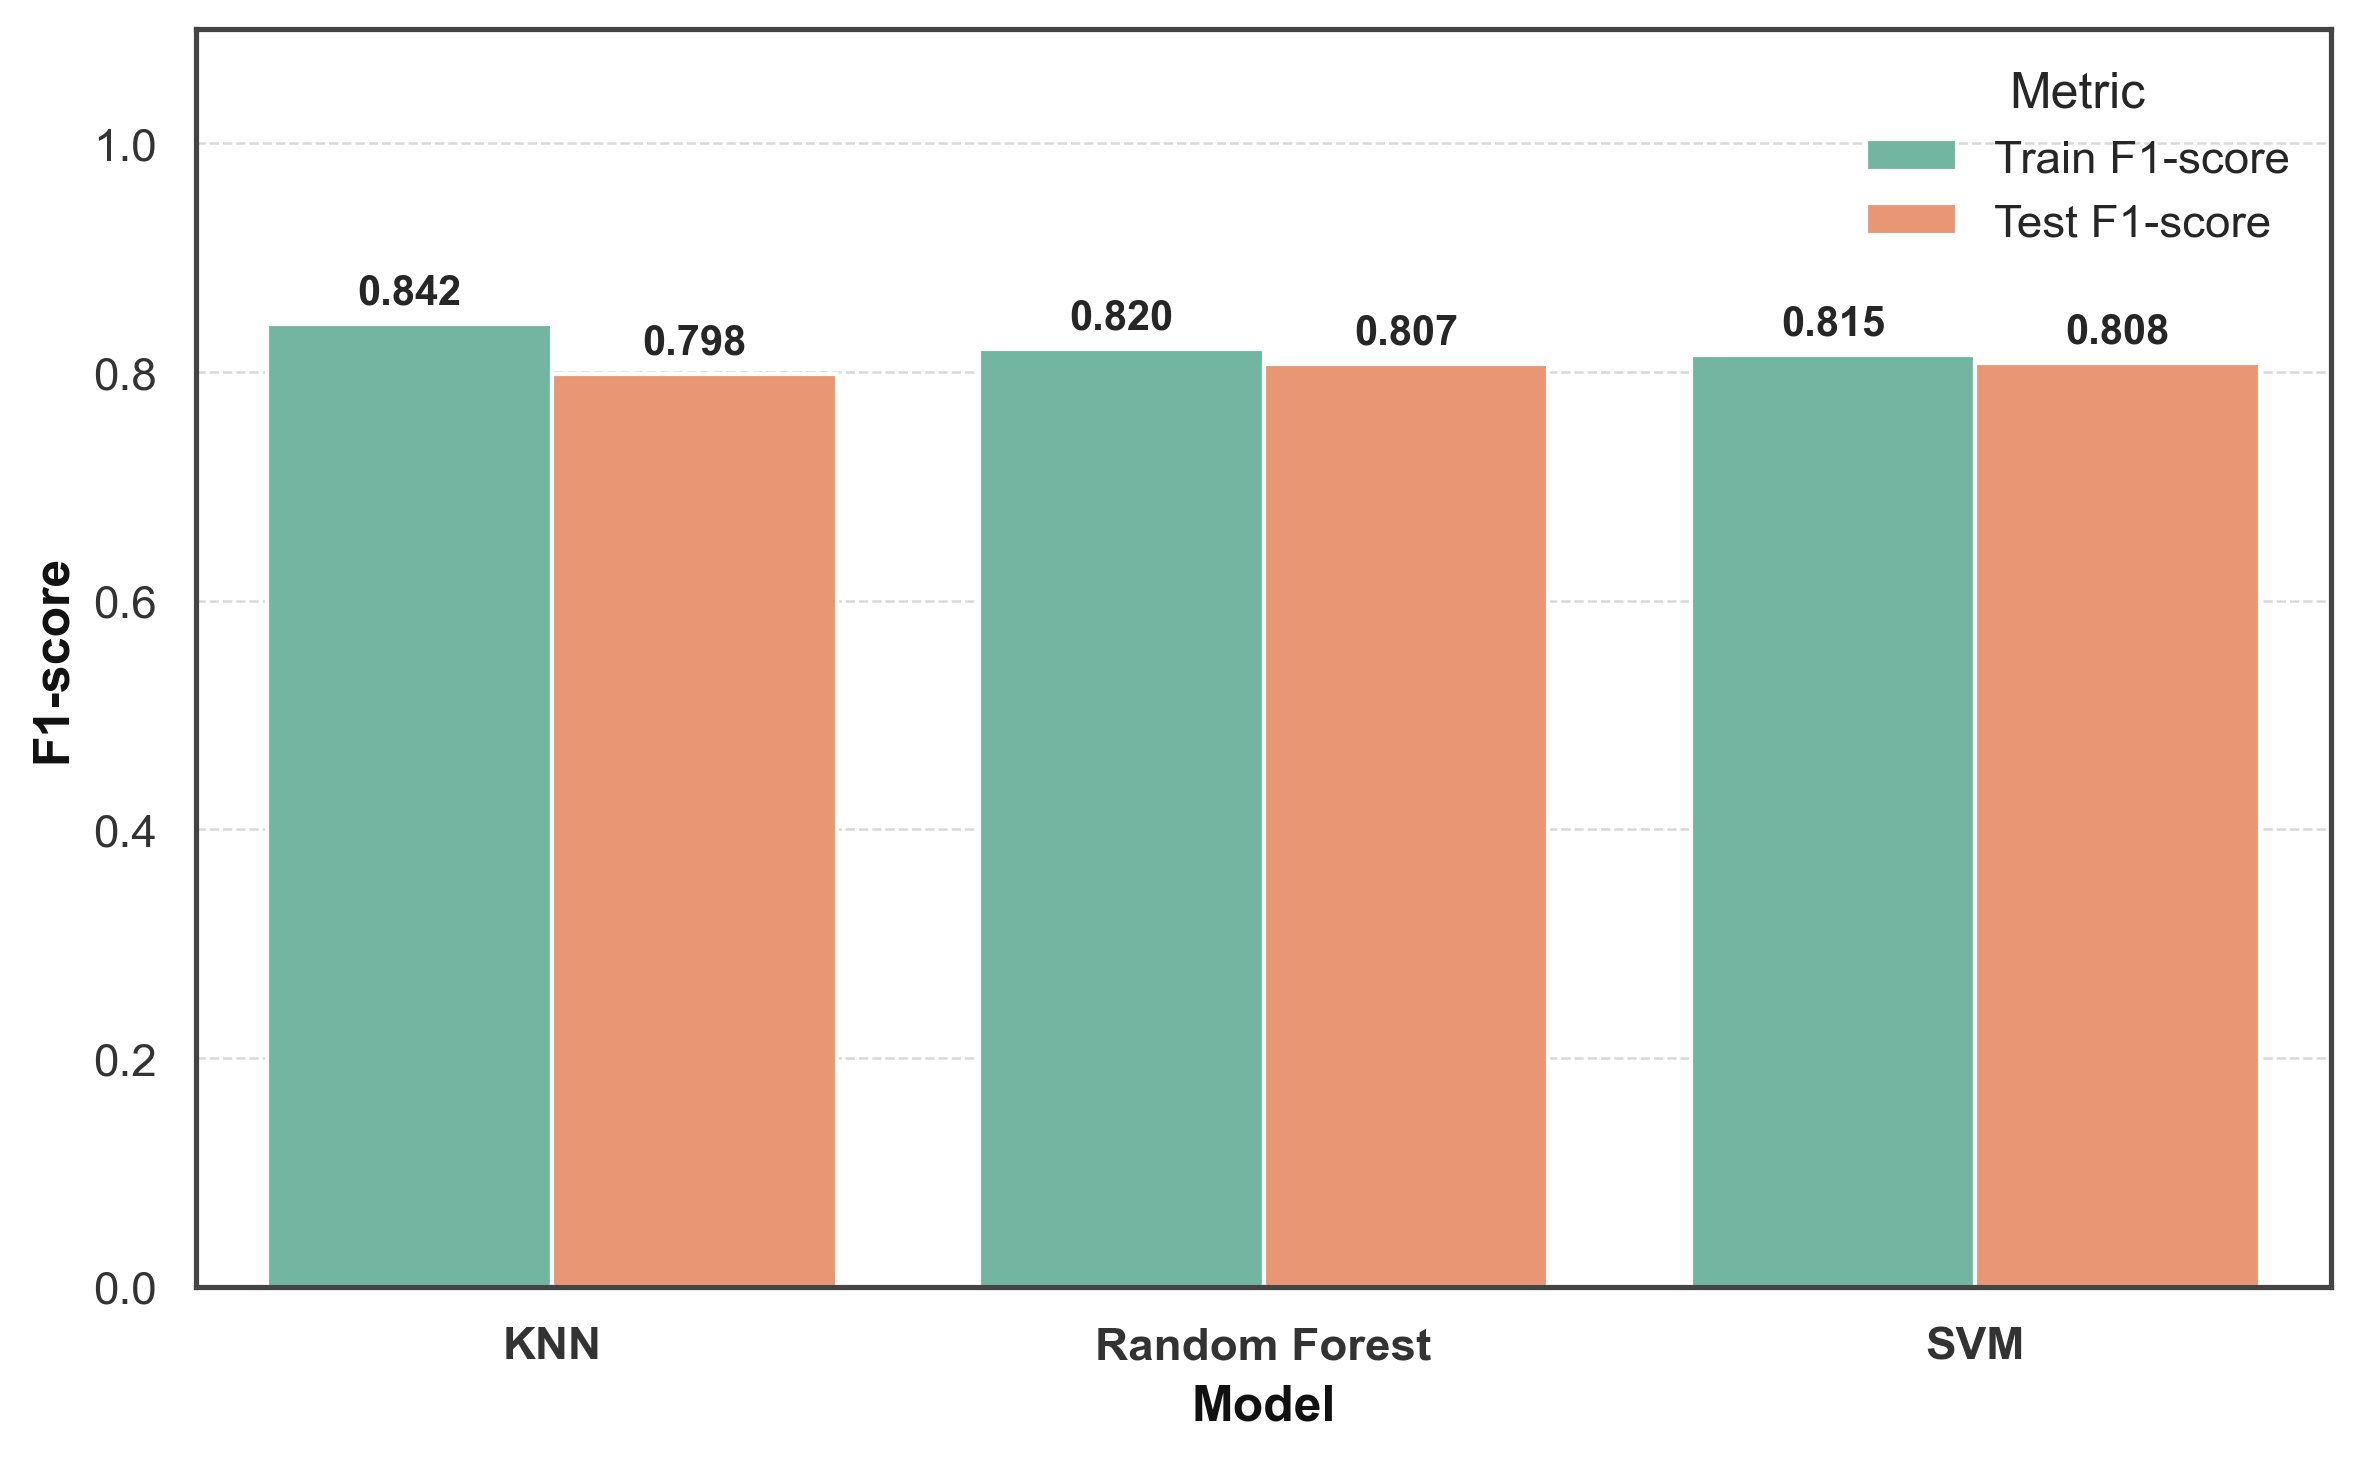

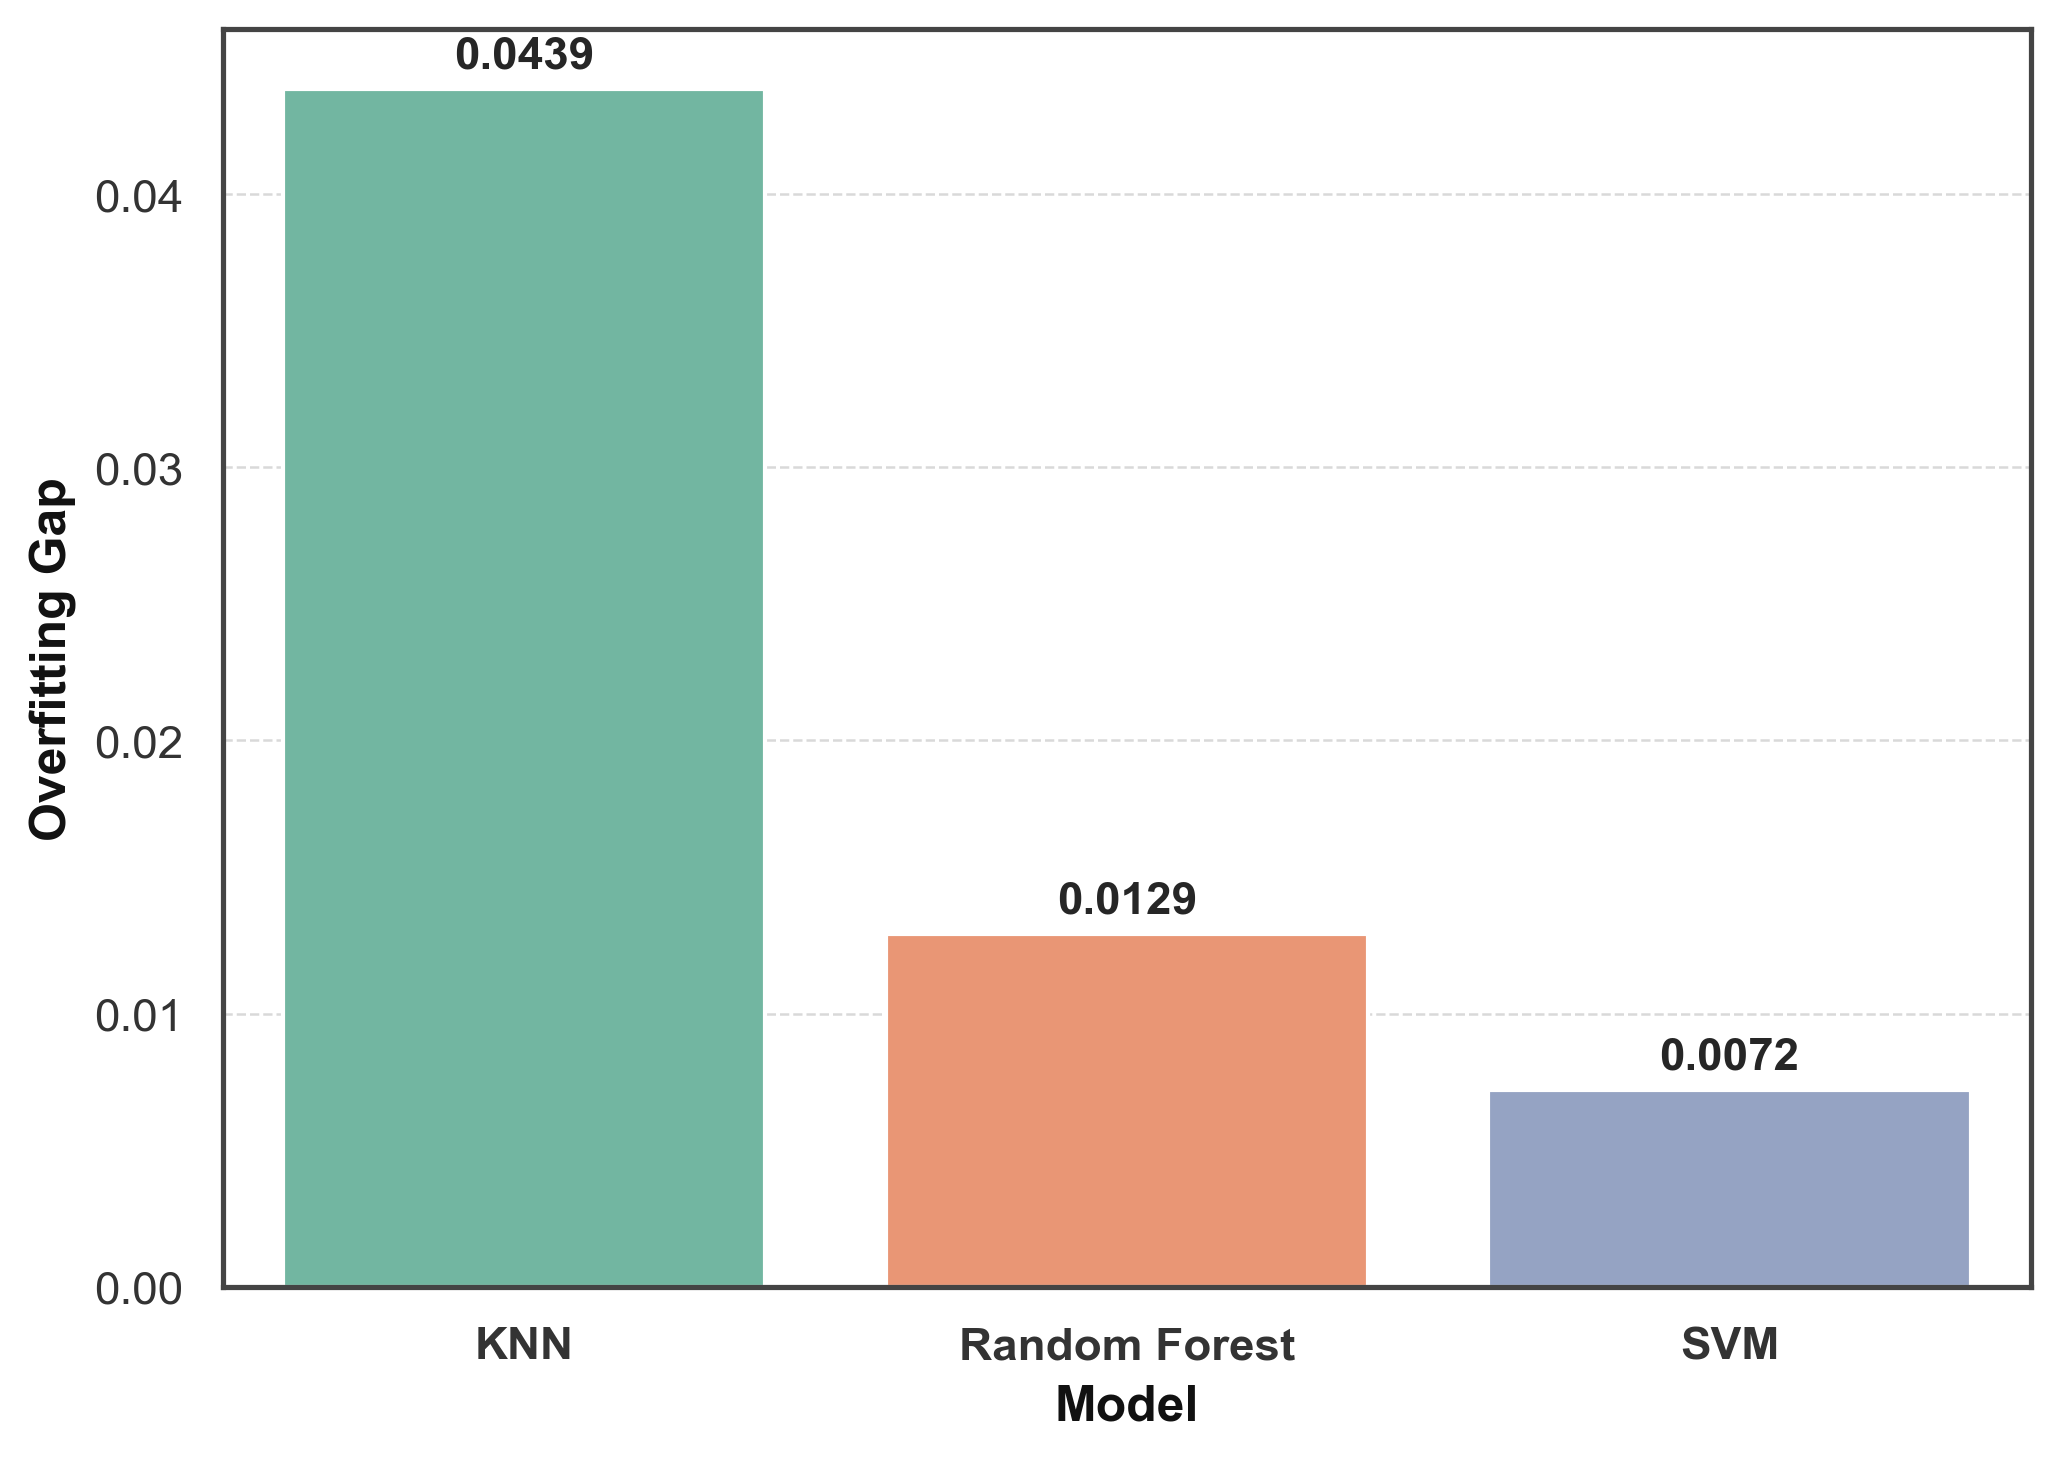

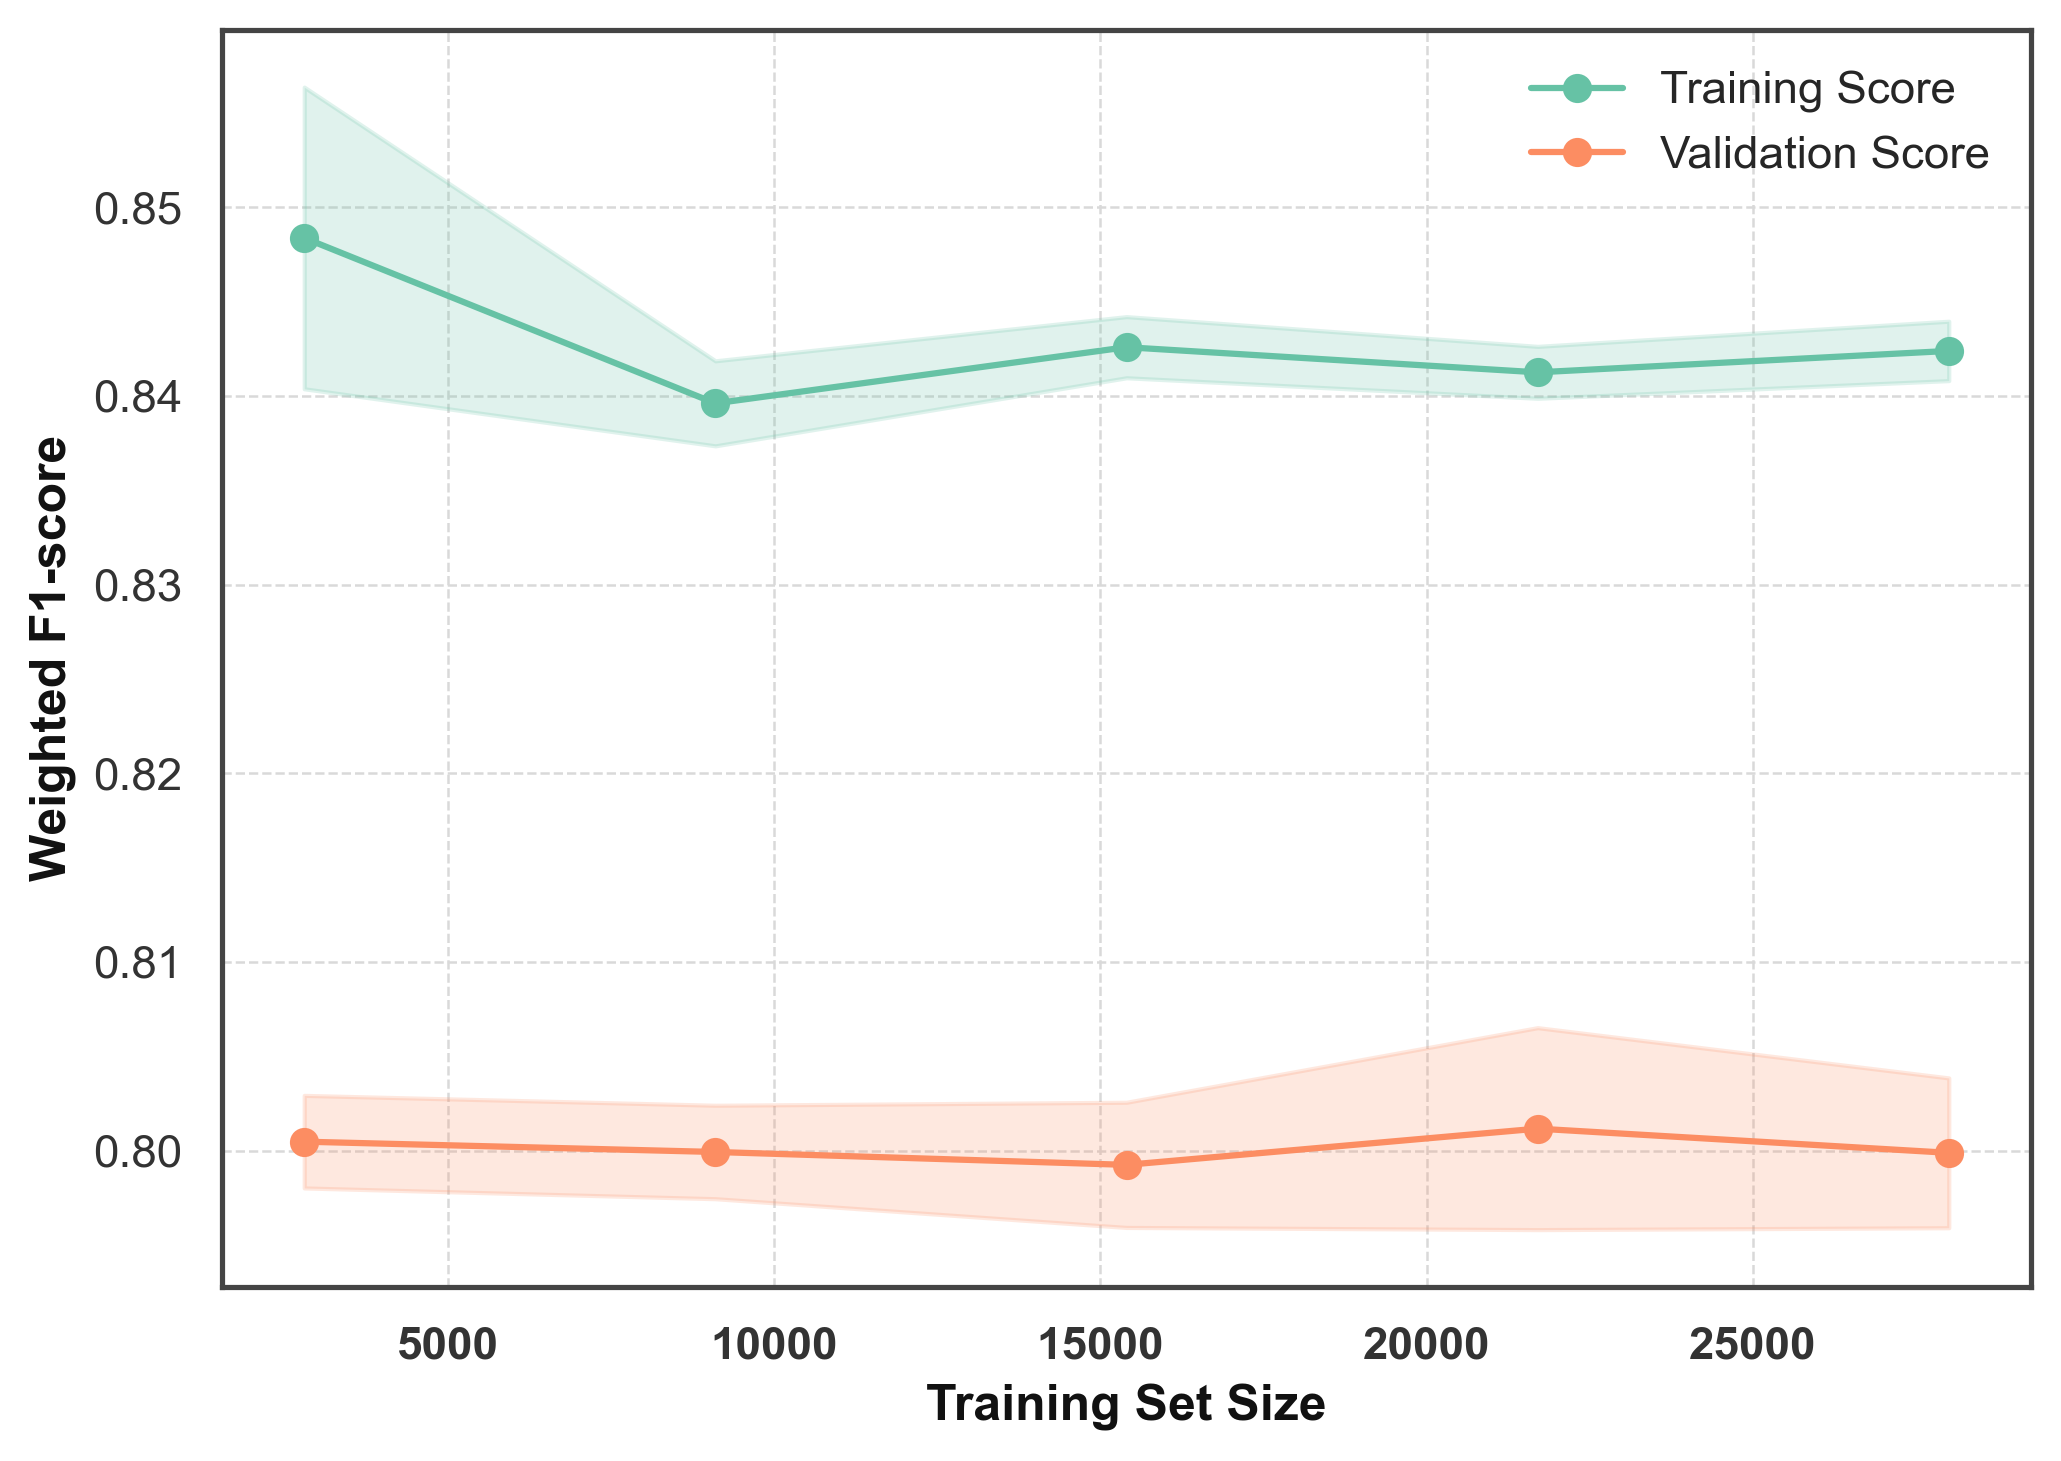

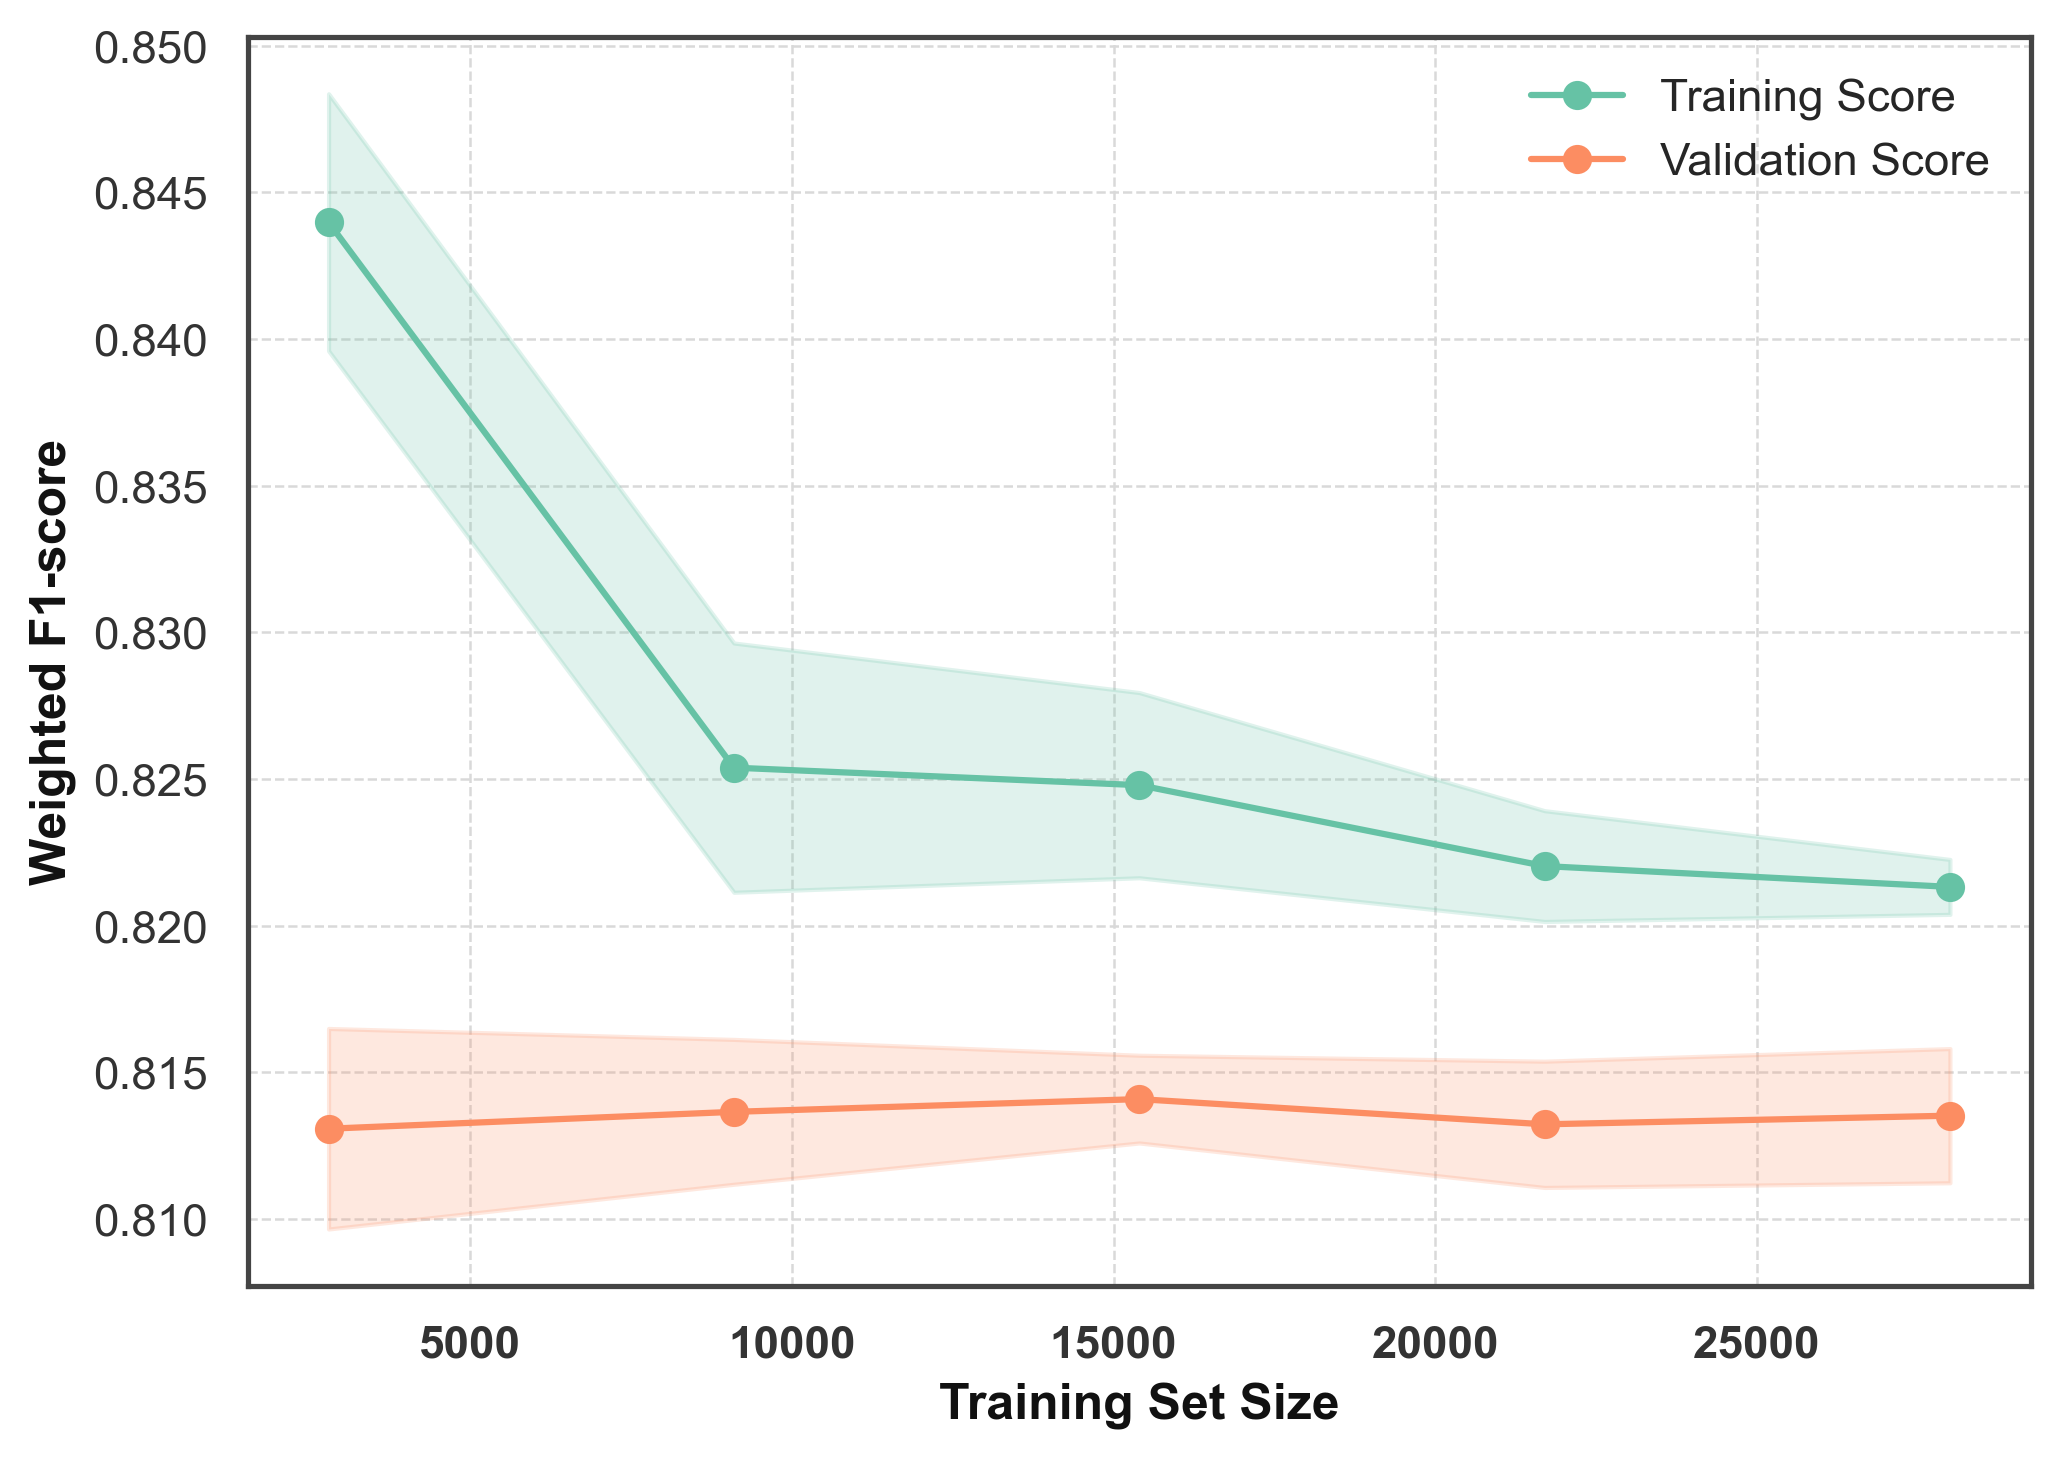

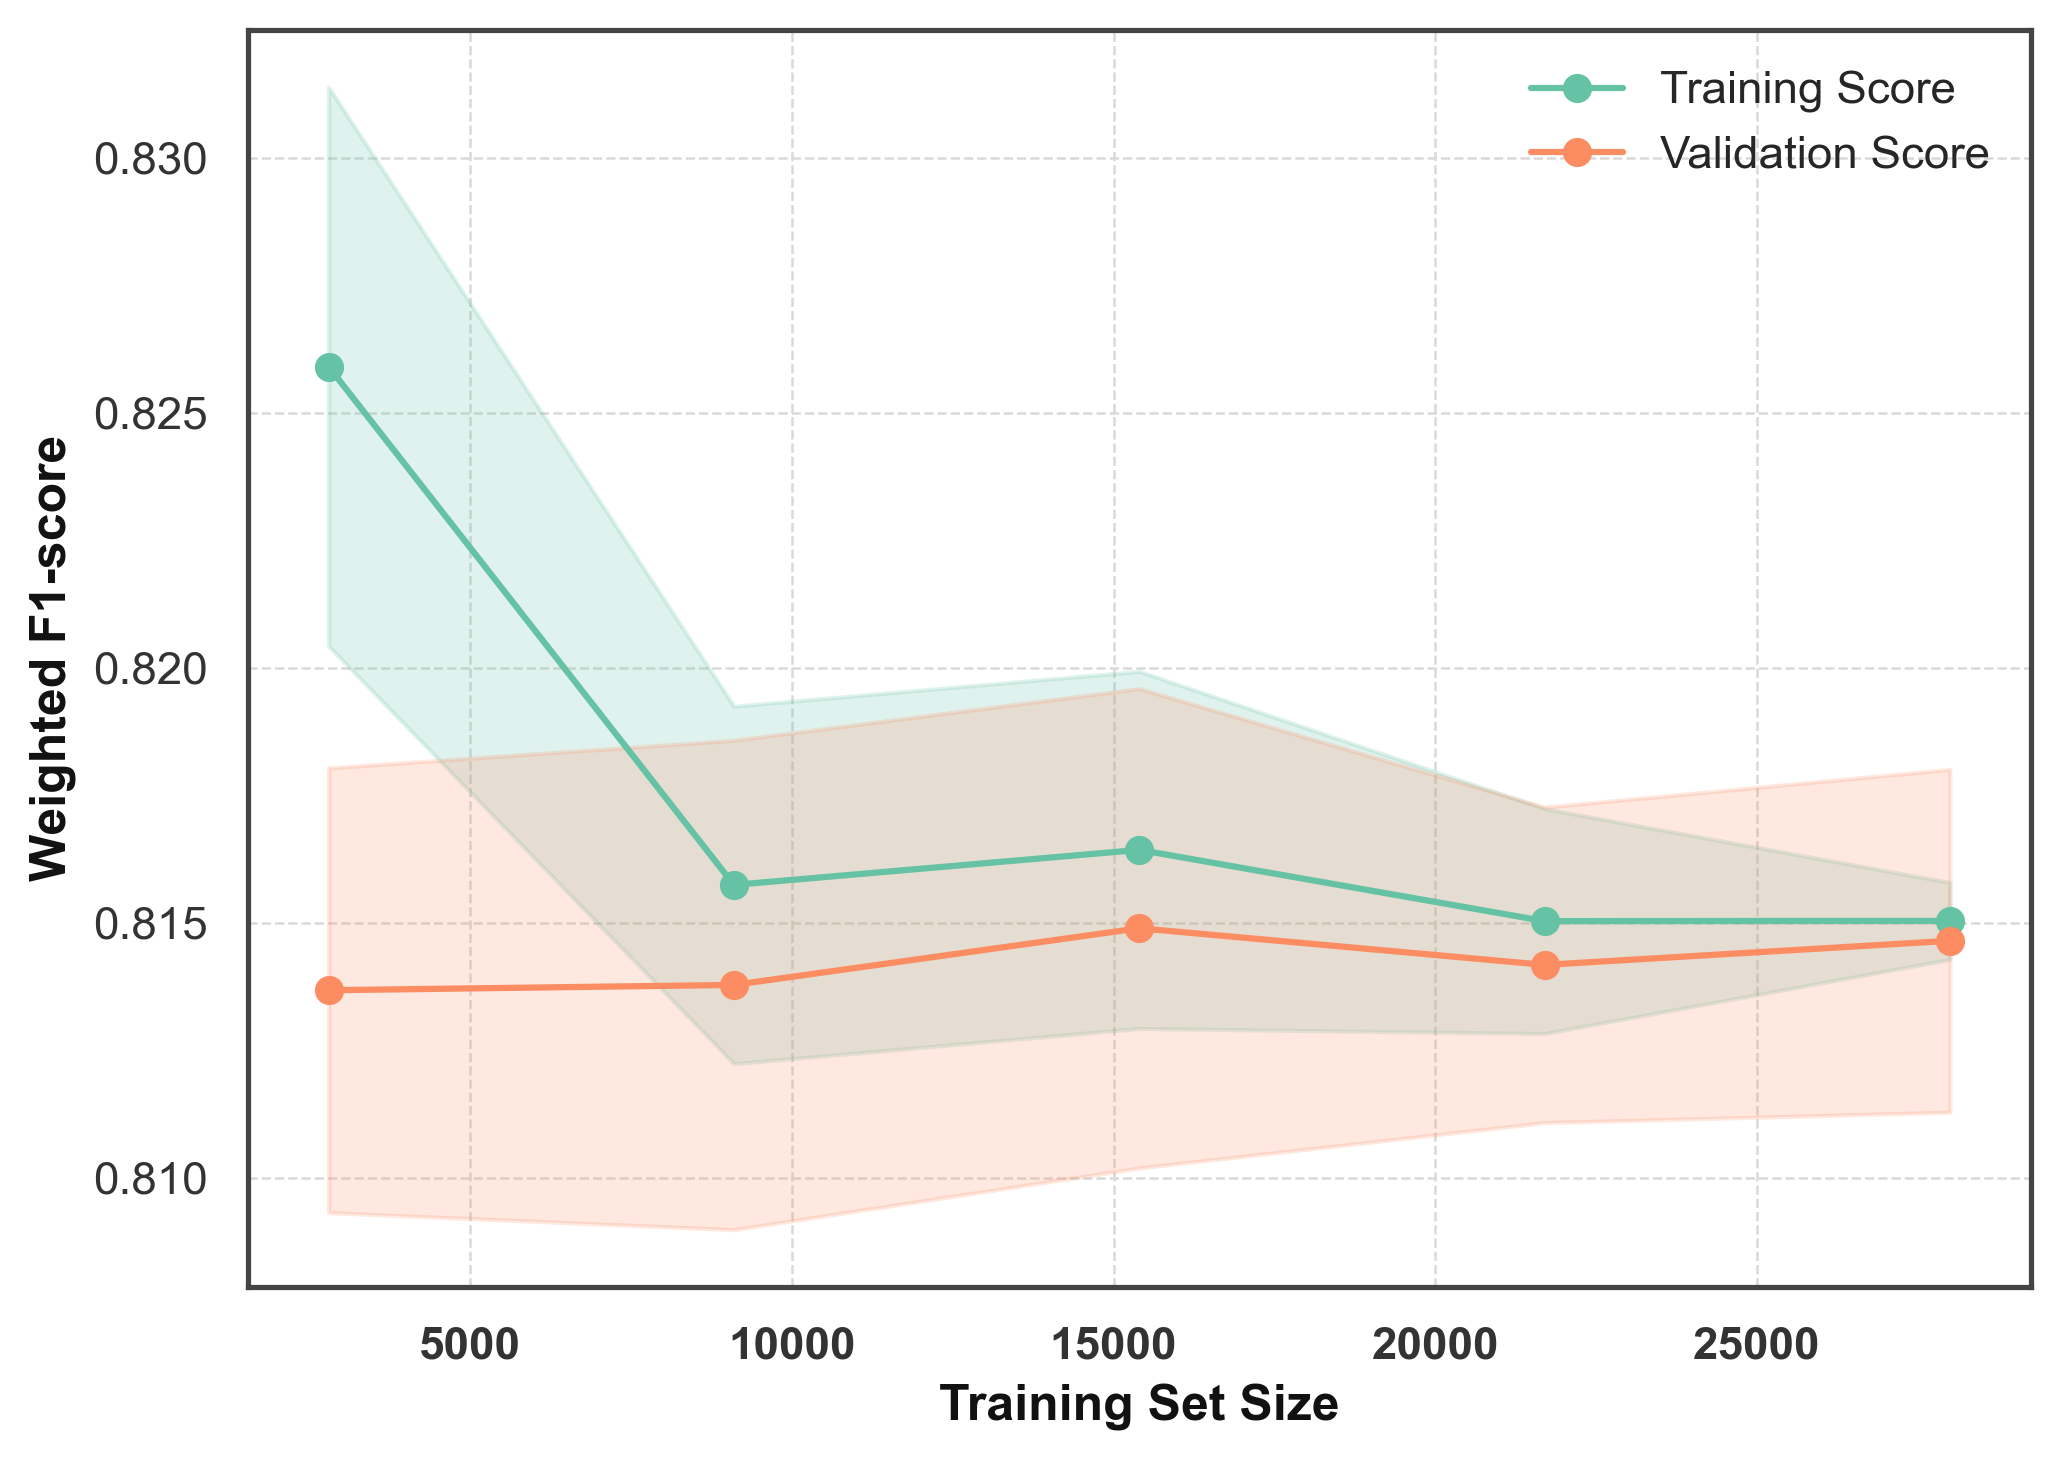


RESULTADOS DEL ANÁLISIS DE OVERFITTING

        Model  Train Accuracy  Test Accuracy  Train F1-score  Test F1-score  Overfitting Gap
          KNN        0.842714       0.799067        0.842078       0.798222         0.043856
Random Forest        0.824057       0.811200        0.820198       0.807291         0.012907
          SVM        0.811514       0.804333        0.814966       0.807746         0.007220

MEJOR MODELO (basado en F1-score de prueba):
🔹 Modelo: SVM
🔹 Train Accuracy: 0.8115
🔹 Test Accuracy: 0.8043
🔹 Train F1-score: 0.8150
🔹 Test F1-score: 0.8077
🔹 Overfitting Gap: 0.0072

📊 TABLA COMPARATIVA:
--------------------------------------------------------------------------------
Modelo          Train Acc  Test Acc   Train F1   Test F1    Gap       
--------------------------------------------------------------------------------
KNN             0.8427    0.7991    0.8421    0.7982    0.0439
Random Forest   0.8241    0.8112    0.8202    0.8073    0.0129
SVM             0.8115

In [1]:
# =====================================================
# CELDA COMPLETA: GRÁFICOS DE BARRAS CON VALORES NUMÉRICOS
# =====================================================

# Importaciones necesarias
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# =====================================================
# GLOBAL STYLE
# =====================================================
sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#111111",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.frameon": False
})

palette = sns.color_palette("Set2")

def format_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=12, color="#111111", fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, color="#111111", fontweight="bold")
    ax.tick_params(axis="x", labelsize=11, colors="#333333")
    ax.tick_params(axis="y", labelsize=11, colors="#333333")
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

# =====================================================
# CREATE FOLDER FOR FIGURES
# =====================================================
os.makedirs("figures", exist_ok=True)

# =====================================================
# LOAD DATASET
# =====================================================
file_path = "pon_synthetic_dataset_50000_overlap.csv"
data = pd.read_csv(file_path)

print("=" * 60)
print("Dataset loaded successfully")
print("Shape:", data.shape)

# =====================================================
# FEATURES AND TARGET
# =====================================================
features = [
    "packet_size_bytes",
    "packets_per_sec",
    "traffic_rate_mbps"
]

X = data[features]
y = data["traffic_type"]

# =====================================================
# 1. FEATURE VISUALIZATION
# =====================================================

# -----------------------------------------------------
# 1.1 Traffic class distribution (CON VALORES NUMÉRICOS)
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax = sns.countplot(
    data=data,
    x="traffic_type",
    palette="Set2",
    order=sorted(data["traffic_type"].unique()),
    ax=ax
)

# Añadir valores en las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold',
                color='#333333')

format_axes(ax, "Traffic Type", "Number of Samples")
plt.tight_layout()
plt.savefig("figures/traffic_class_distribution.png")
plt.show()

# -----------------------------------------------------
# 1.2 Scatter plot: packets_per_sec vs traffic_rate_mbps
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=data.sample(5000, random_state=42),
    x="packets_per_sec",
    y="traffic_rate_mbps",
    hue="traffic_type",
    palette="Set2",
    alpha=0.6,
    ax=ax
)

format_axes(ax, "Packets per Second", "Traffic Rate (Mbps)")
ax.legend(title="Traffic Type")
plt.tight_layout()
plt.savefig("figures/scatter_packets_vs_rate.png")
plt.show()

# -----------------------------------------------------
# 1.3 Scatter plot: packet_size_bytes vs traffic_rate_mbps
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=data.sample(5000, random_state=42),
    x="packet_size_bytes",
    y="traffic_rate_mbps",
    hue="traffic_type",
    palette="Set2",
    alpha=0.6,
    ax=ax
)

format_axes(ax, "Packet Size (Bytes)", "Traffic Rate (Mbps)")
ax.legend(title="Traffic Type")
plt.tight_layout()
plt.savefig("figures/scatter_packet_size_vs_rate.png")
plt.show()

# -----------------------------------------------------
# 1.4 Pairplot of core traffic features
# -----------------------------------------------------
sample_data = data.sample(2000, random_state=42)

pairplot = sns.pairplot(
    sample_data,
    vars=features,
    hue="traffic_type",
    palette="Set2",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 20}
)

pairplot.savefig("figures/pairplot_features.png")
plt.show()

# =====================================================
# 2. OVERFITTING ANALYSIS
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=0.3,
            gamma="scale",
            class_weight="balanced"
        ))
    ])
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train F1-score": train_f1,
        "Test F1-score": test_f1,
        "Overfitting Gap": train_f1 - test_f1
    })

results_df = pd.DataFrame(results)
print("\nOverfitting Analysis:")
print(results_df)

results_df.to_csv("overfitting_analysis_results.csv", index=False)

# =====================================================
# 3. GRÁFICOS DE BARRAS CON VALORES NUMÉRICOS
# =====================================================

# -----------------------------------------------------
# 3.1 Train vs Test performance (CON VALORES NUMÉRICOS)
# -----------------------------------------------------
comparison_df = results_df.melt(
    id_vars="Model",
    value_vars=["Train F1-score", "Test F1-score"],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = sns.barplot(
    data=comparison_df,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2",
    ax=ax
)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, fontweight='bold', padding=3)

format_axes(ax, "Model", "F1-score")
ax.set_ylim(0, 1.1)  # Ajustado para dejar espacio para las etiquetas
ax.legend(title="Metric")
plt.tight_layout()
plt.savefig("figures/train_test_f1_comparison.png")
plt.show()

# -----------------------------------------------------
# 3.2 Overfitting gap (CON VALORES NUMÉRICOS)
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
bars = sns.barplot(
    data=results_df,
    x="Model",
    y="Overfitting Gap",
    palette="Set2",
    ax=ax
)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=11, fontweight='bold', padding=3)

format_axes(ax, "Model", "Overfitting Gap")
plt.tight_layout()
plt.savefig("figures/overfitting_gap.png")
plt.show()

# -----------------------------------------------------
# 3.3 Learning curves
# -----------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def plot_learning_curve(estimator, X_data, y_data, model_name):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_data,
        y_data,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(train_sizes, train_mean, marker="o", label="Training Score", color=palette[0])
    ax.plot(train_sizes, val_mean, marker="o", label="Validation Score", color=palette[1])

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
        color=palette[0]
    )
    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2,
        color=palette[1]
    )

    format_axes(ax, "Training Set Size", "Weighted F1-score")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"figures/learning_curve_{model_name}.png")
    plt.show()

for model_name, model in models.items():
    plot_learning_curve(model, X_train, y_train, model_name.replace(" ", "_"))

# =====================================================
# 4. TABLA RESUMEN CON RESULTADOS
# =====================================================
print("\n" + "="*60)
print("RESULTADOS DEL ANÁLISIS DE OVERFITTING")
print("="*60)
print("\n" + results_df.to_string(index=False))

# Identificar el mejor modelo
best_model = results_df.loc[results_df["Test F1-score"].idxmax()]
print("\n" + "="*60)
print("MEJOR MODELO (basado en F1-score de prueba):")
print(f"🔹 Modelo: {best_model['Model']}")
print(f"🔹 Train Accuracy: {best_model['Train Accuracy']:.4f}")
print(f"🔹 Test Accuracy: {best_model['Test Accuracy']:.4f}")
print(f"🔹 Train F1-score: {best_model['Train F1-score']:.4f}")
print(f"🔹 Test F1-score: {best_model['Test F1-score']:.4f}")
print(f"🔹 Overfitting Gap: {best_model['Overfitting Gap']:.4f}")
print("="*60)

# Mostrar todos los resultados en formato tabla
print("\n📊 TABLA COMPARATIVA:")
print("-" * 80)
print(f"{'Modelo':<15} {'Train Acc':<10} {'Test Acc':<10} {'Train F1':<10} {'Test F1':<10} {'Gap':<10}")
print("-" * 80)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<15} {row['Train Accuracy']:.4f}    {row['Test Accuracy']:.4f}    "
          f"{row['Train F1-score']:.4f}    {row['Test F1-score']:.4f}    {row['Overfitting Gap']:.4f}")
print("-" * 80)

print("\n✅ Análisis completado. Archivos guardados en la carpeta 'figures/'")


Evaluating computational cost for KNN

Evaluating computational cost for Random Forest

Evaluating computational cost for SVM

Computational Complexity Results
           Model  Training Time (s)  Inference Time (s)  \
0            KNN           0.103764            1.174313   
1  Random Forest           0.769779            0.097489   
2            SVM          31.129903           26.191341   

   Inference per Sample (ms)  Model Size (KB)  
0                   0.078288      1528.854492  
1                   0.006499      1394.294922  
2                   1.746089       717.693359  


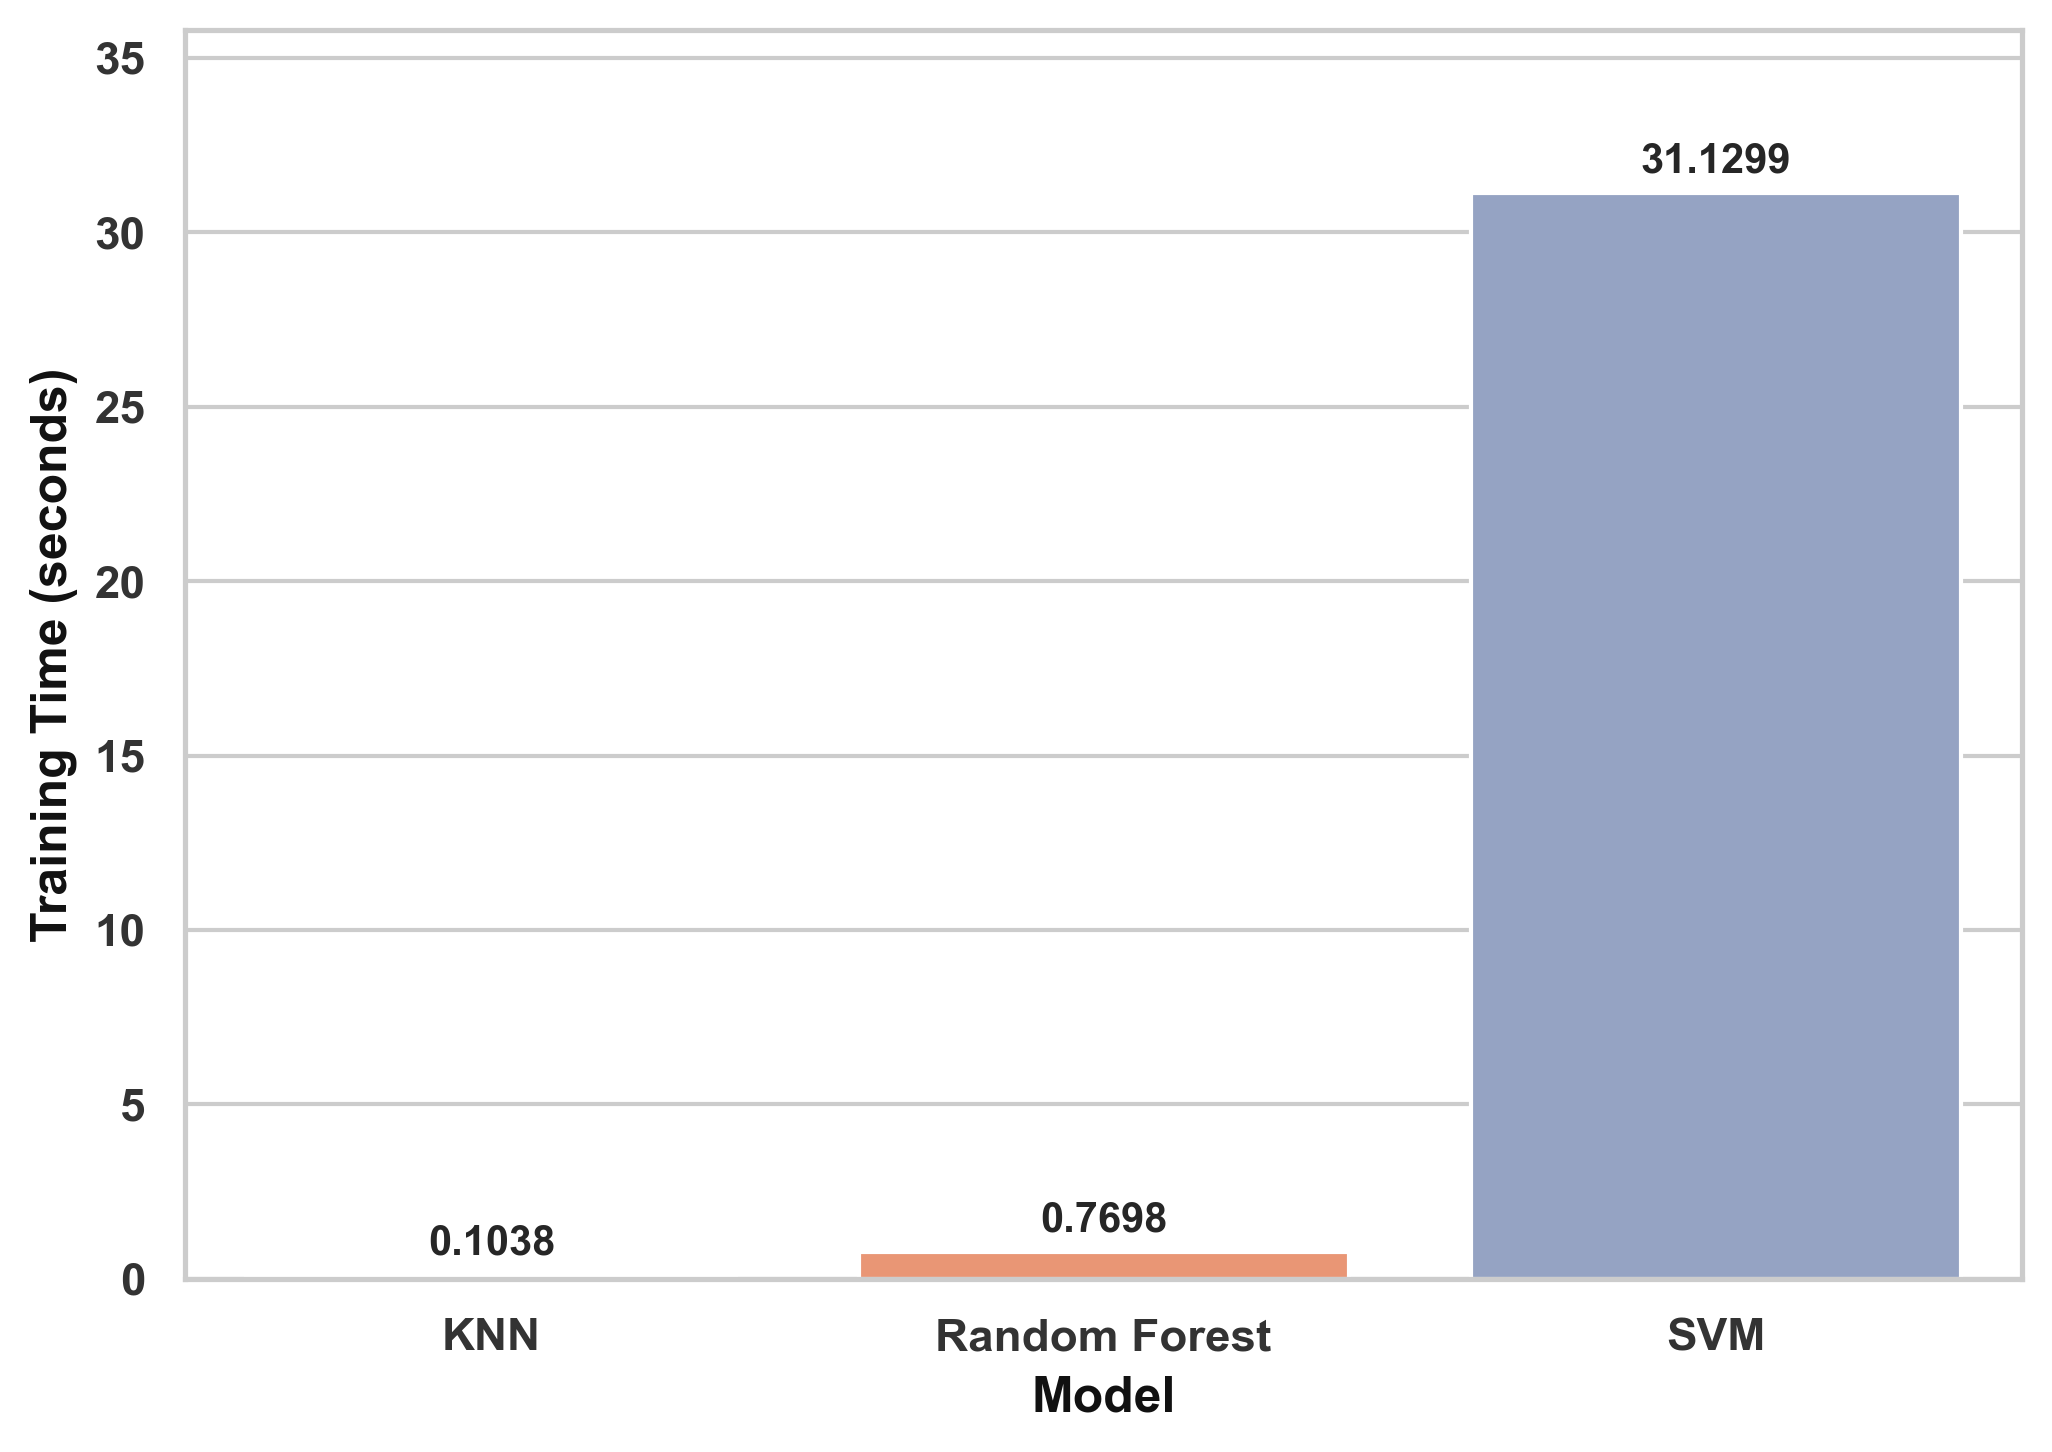

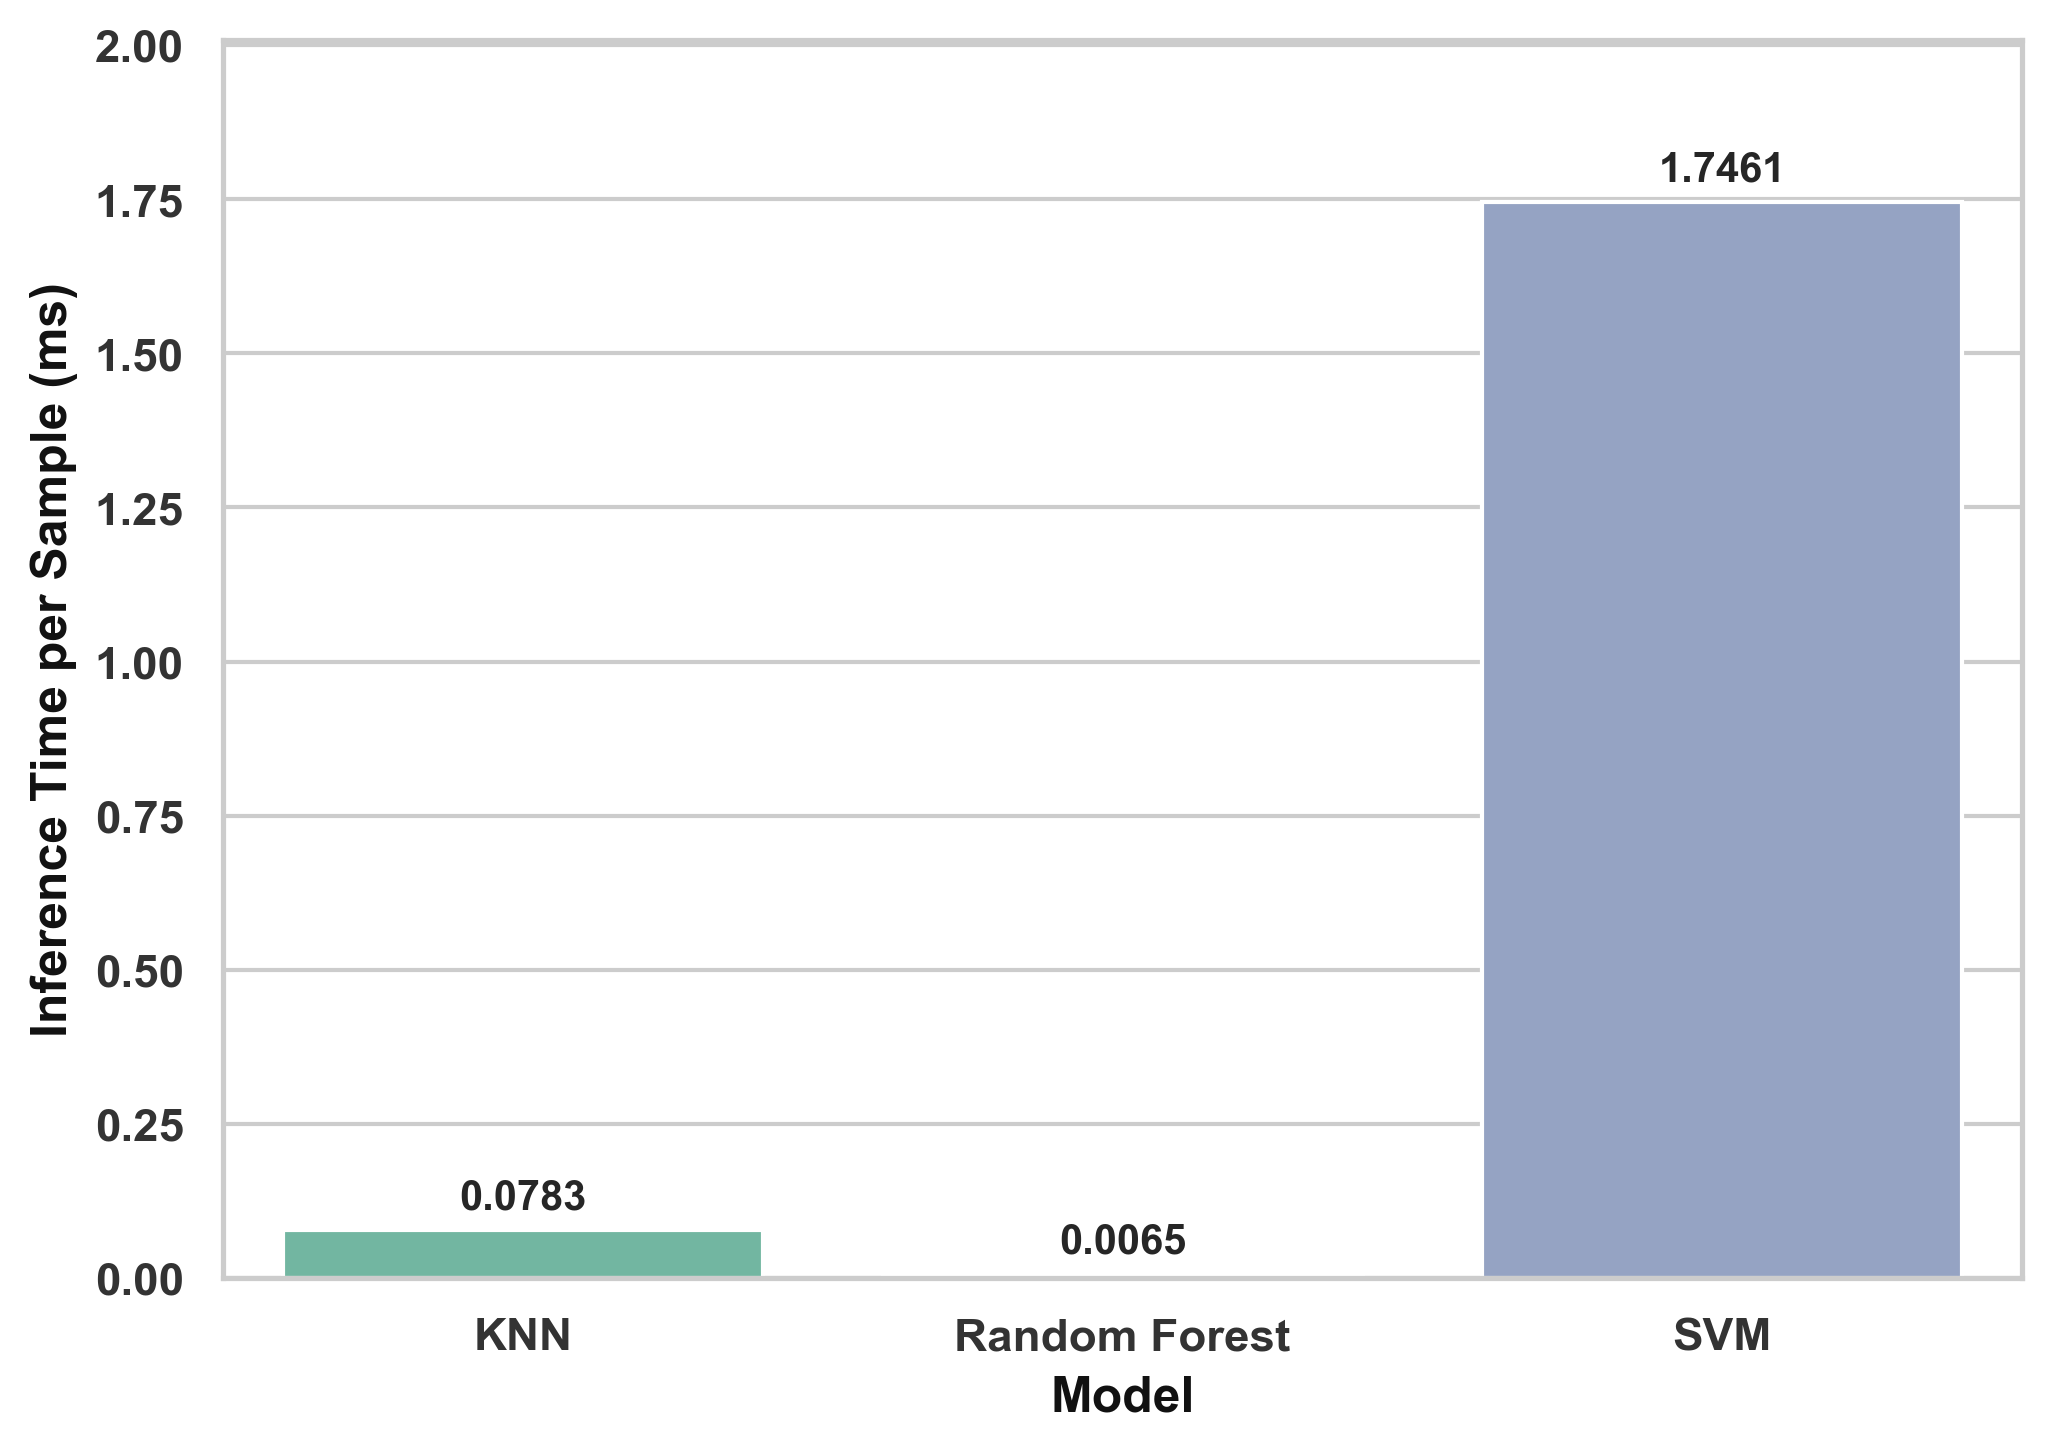

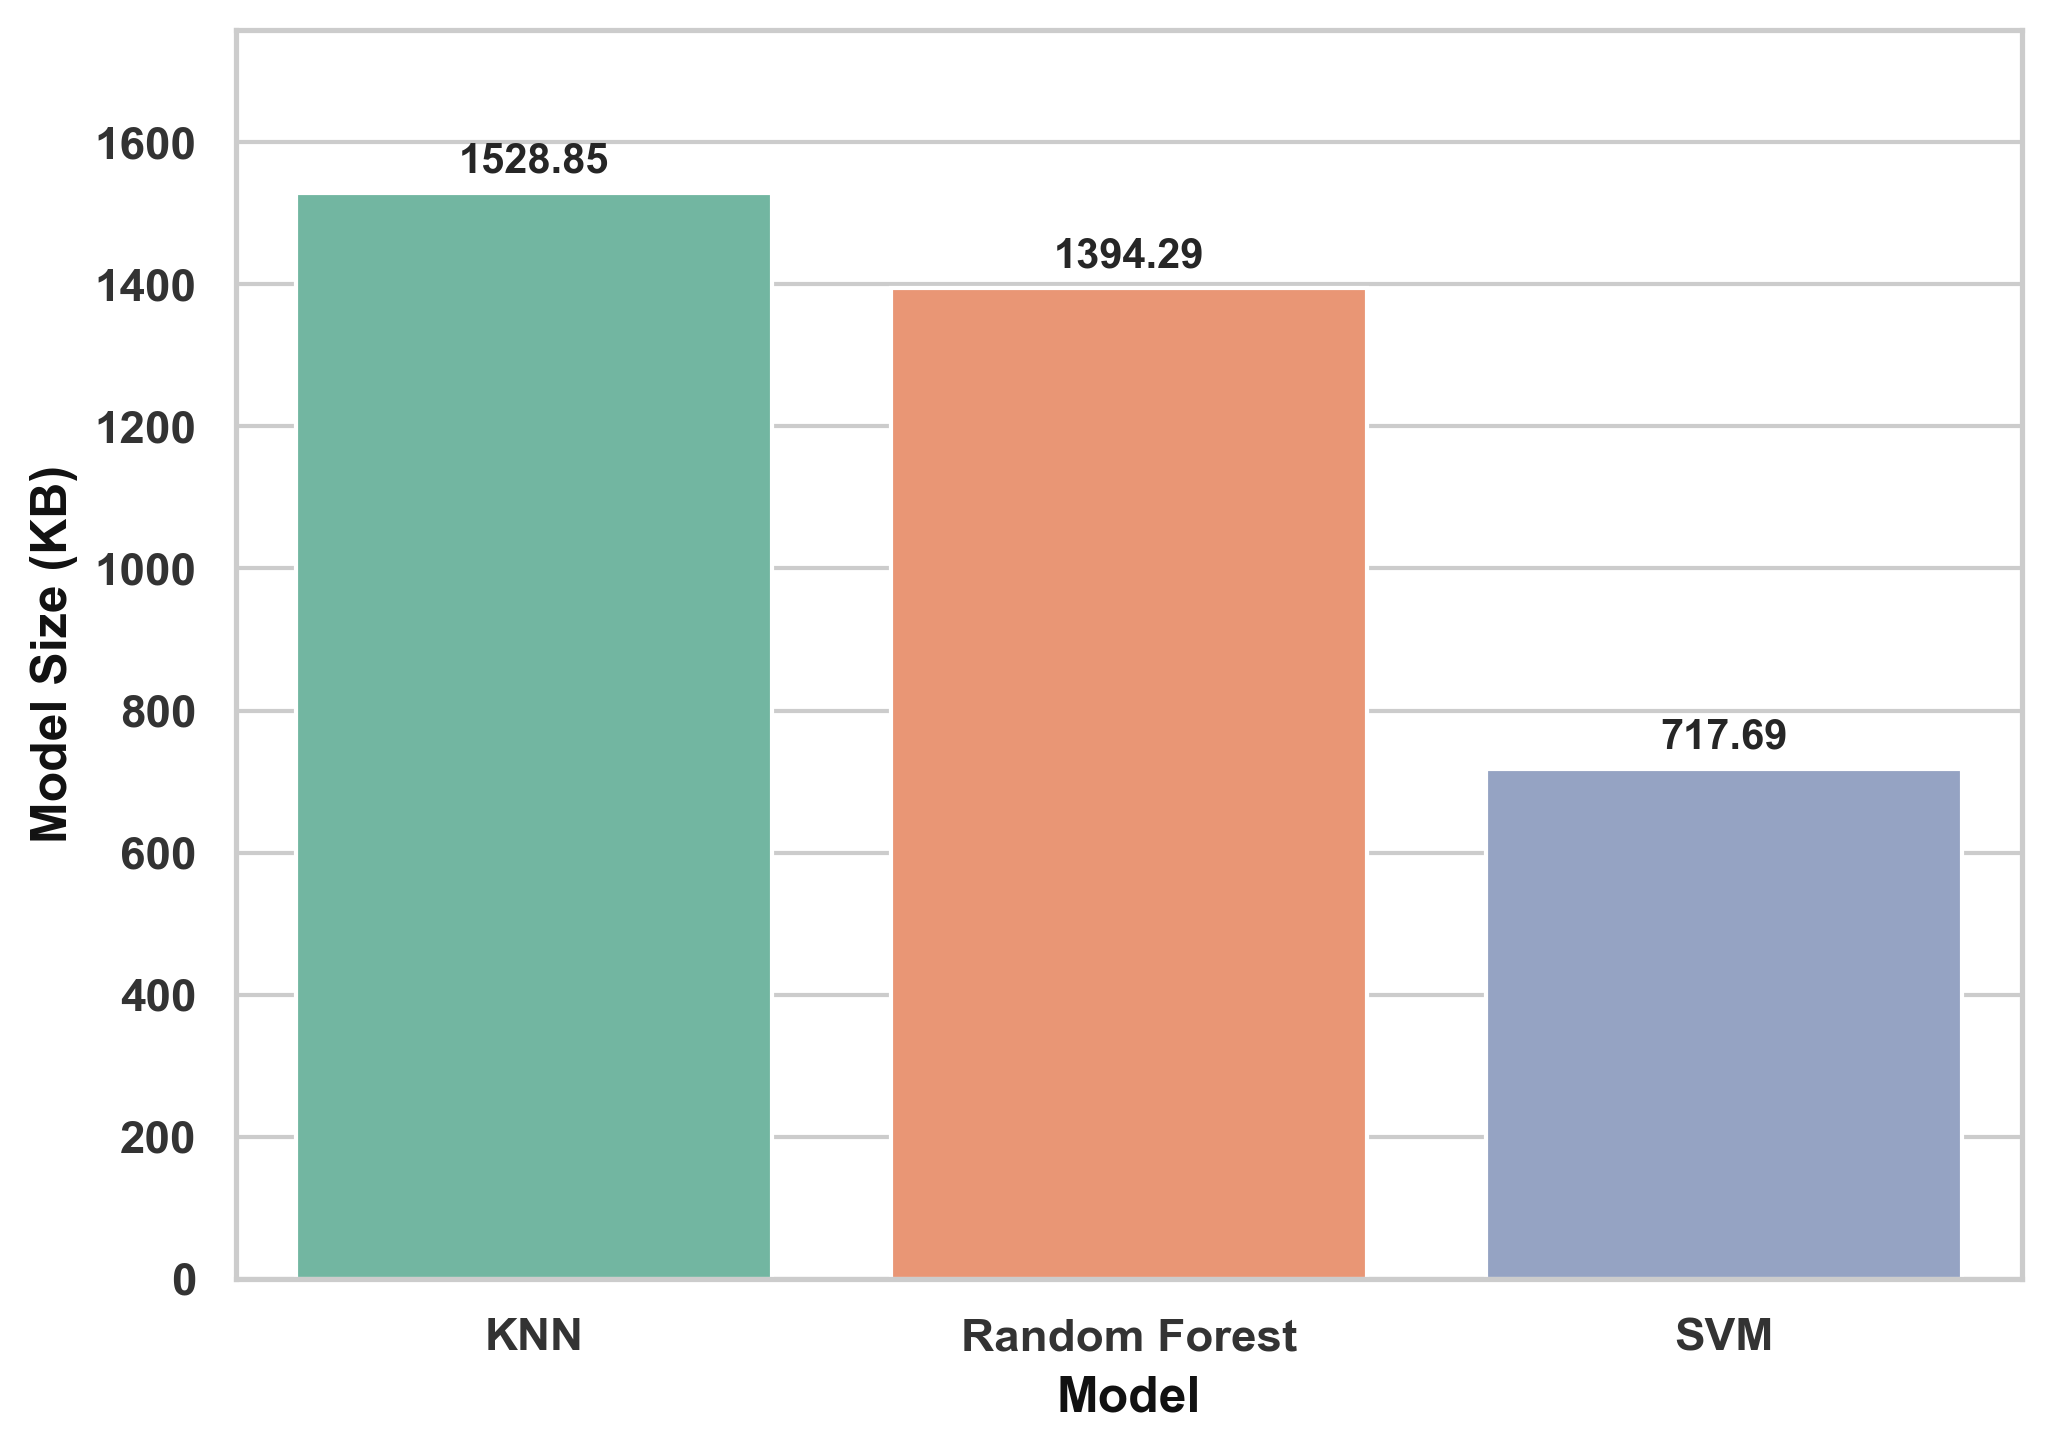


RESULTADOS DE ANÁLISIS DE COSTO COMPUTACIONAL

        Model  Training Time (s)  Inference Time (s)  Inference per Sample (ms)  Model Size (KB)
          KNN           0.103764            1.174313                   0.078288      1528.854492
Random Forest           0.769779            0.097489                   0.006499      1394.294922
          SVM          31.129903           26.191341                   1.746089       717.693359

MEJORES MODELOS POR MÉTRICA:
🔹 Entrenamiento más rápido: KNN (0.1038 s)
🔹 Inferencia más rápida: Random Forest (0.0065 ms/muestra)
🔹 Modelo más pequeño: SVM (717.69 KB)

📊 TABLA COMPARATIVA DE COMPLEJIDAD:
------------------------------------------------------------------------------------------
Modelo          Training Time (s)  Inference (ms)  Model Size (KB)
------------------------------------------------------------------------------------------
KNN             0.1038 s         0.0783 ms       1528.85 KB
Random Forest   0.7698 s         0.0065 ms      

In [2]:
import time
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")

# =====================================================
# COMPUTATIONAL COST ANALYSIS
# =====================================================

complexity_results = []

for model_name, model in models.items():

    print(f"\nEvaluating computational cost for {model_name}")

    # ------------------------------
    # TRAINING TIME
    # ------------------------------
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()

    training_time = end_train - start_train

    # ------------------------------
    # INFERENCE TIME
    # ------------------------------
    start_pred = time.perf_counter()
    y_pred = model.predict(X_test)
    end_pred = time.perf_counter()

    inference_time = end_pred - start_pred

    inference_per_sample = inference_time / len(X_test)

    # ------------------------------
    # MODEL SIZE
    # ------------------------------
    model_bytes = pickle.dumps(model)
    model_size_kb = len(model_bytes) / 1024

    complexity_results.append({
        "Model": model_name,
        "Training Time (s)": training_time,
        "Inference Time (s)": inference_time,
        "Inference per Sample (ms)": inference_per_sample * 1000,
        "Model Size (KB)": model_size_kb
    })

complexity_df = pd.DataFrame(complexity_results)

print("\nComputational Complexity Results")
print(complexity_df)

complexity_df.to_csv("computational_cost_results.csv", index=False)

# =====================================================
# FIGURE 1: TRAINING TIME (CON VALORES)
# =====================================================

fig, ax = plt.subplots(figsize=(7,5))

bars = sns.barplot(
    data=complexity_df,
    x="Model",
    y="Training Time (s)",
    palette="Set2",
    ax=ax
)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=10, fontweight='bold', padding=3)

var = "Model"
kpi = "Training Time (seconds)"

ax.set_xlabel(var, fontsize=12, color='#111111', fontweight='bold')
ax.set_ylabel(kpi, fontsize=12, color='#111111', fontweight='bold')

# Ajustar límite y para dejar espacio a las etiquetas
max_val = complexity_df["Training Time (s)"].max()
ax.set_ylim(0, max_val * 1.15)

plt.xticks(fontsize=11, color='#333333', fontweight='bold')
plt.yticks(fontsize=11, color='#333333', fontweight='bold')

plt.tight_layout()
plt.savefig("figures/training_time_models.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# FIGURE 2: INFERENCE TIME (CON VALORES)
# =====================================================

fig, ax = plt.subplots(figsize=(7,5))

bars = sns.barplot(
    data=complexity_df,
    x="Model",
    y="Inference per Sample (ms)",
    palette="Set2",
    ax=ax
)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=10, fontweight='bold', padding=3)

var = "Model"
kpi = "Inference Time per Sample (ms)"

ax.set_xlabel(var, fontsize=12, color='#111111', fontweight='bold')
ax.set_ylabel(kpi, fontsize=12, color='#111111', fontweight='bold')

# Ajustar límite y para dejar espacio a las etiquetas
max_val = complexity_df["Inference per Sample (ms)"].max()
ax.set_ylim(0, max_val * 1.15)

plt.xticks(fontsize=11, color='#333333', fontweight='bold')
plt.yticks(fontsize=11, color='#333333', fontweight='bold')

plt.tight_layout()
plt.savefig("figures/inference_time_models.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# FIGURE 3: MODEL SIZE (CON VALORES)
# =====================================================

fig, ax = plt.subplots(figsize=(7,5))

bars = sns.barplot(
    data=complexity_df,
    x="Model",
    y="Model Size (KB)",
    palette="Set2",
    ax=ax
)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, fontweight='bold', padding=3)

var = "Model"
kpi = "Model Size (KB)"

ax.set_xlabel(var, fontsize=12, color='#111111', fontweight='bold')
ax.set_ylabel(kpi, fontsize=12, color='#111111', fontweight='bold')

# Ajustar límite y para dejar espacio a las etiquetas
max_val = complexity_df["Model Size (KB)"].max()
ax.set_ylim(0, max_val * 1.15)

plt.xticks(fontsize=11, color='#333333', fontweight='bold')
plt.yticks(fontsize=11, color='#333333', fontweight='bold')

plt.tight_layout()
plt.savefig("figures/model_size_models.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# TABLA RESUMEN CON RESULTADOS
# =====================================================
print("\n" + "="*60)
print("RESULTADOS DE ANÁLISIS DE COSTO COMPUTACIONAL")
print("="*60)
print("\n" + complexity_df.to_string(index=False))

# Identificar mejor modelo por cada métrica
fastest_training = complexity_df.loc[complexity_df["Training Time (s)"].idxmin()]
fastest_inference = complexity_df.loc[complexity_df["Inference per Sample (ms)"].idxmin()]
smallest_model = complexity_df.loc[complexity_df["Model Size (KB)"].idxmin()]

print("\n" + "="*60)
print("MEJORES MODELOS POR MÉTRICA:")
print(f"🔹 Entrenamiento más rápido: {fastest_training['Model']} ({fastest_training['Training Time (s)']:.4f} s)")
print(f"🔹 Inferencia más rápida: {fastest_inference['Model']} ({fastest_inference['Inference per Sample (ms)']:.4f} ms/muestra)")
print(f"🔹 Modelo más pequeño: {smallest_model['Model']} ({smallest_model['Model Size (KB)']:.2f} KB)")
print("="*60)

# Mostrar todos los resultados en formato tabla
print("\n📊 TABLA COMPARATIVA DE COMPLEJIDAD:")
print("-" * 90)
print(f"{'Modelo':<15} {'Training Time (s)':<18} {'Inference (ms)':<15} {'Model Size (KB)':<15}")
print("-" * 90)
for _, row in complexity_df.iterrows():
    print(f"{row['Model']:<15} {row['Training Time (s)']:.4f} s         {row['Inference per Sample (ms)']:.4f} ms       {row['Model Size (KB)']:.2f} KB")
print("-" * 90)

print("\n✅ Análisis de costo computacional completado.")
print("Archivos guardados:")
print("- computational_cost_results.csv")
print("- figures/training_time_models.png")
print("- figures/inference_time_models.png")
print("- figures/model_size_models.png")